# 🎬 미션 16. 영화 데이터 수집 및 흥행 분석

## 1. 프로젝트 개요

본 프로젝트에서는 웹 스크래핑과 Open API를 활용하여 영화 데이터를 직접 수집하고,
영화의 작품 특성·전문가 평가·실제 흥행 성과를 함께 분석한다.

씨네21에서는 현재 박스오피스 상위 영화의 기본 정보와 상세 정보,
전문가 별점 및 20자평을 수집하고,
KOBIS 일별 박스오피스 API를 통해 영화별 관객수·매출액·스크린 수·상영 횟수 등의 데이터를 수집한다.

수집한 데이터를 바탕으로 현재 흥행 영화의 특징을 살펴보고,
전문가 평가와 흥행 성과의 관계 및 시간에 따른 관객수 패턴을 분석하고자 한다.

## 2. 데이터 수집

### 2.1 씨네21 박스오피스 데이터 수집

씨네21 메인 페이지의 박스오피스 영역에서 현재 상위 10편의 영화 정보를 수집한다.

웹 페이지 요청에는 `requests`를 사용하고, HTML 파싱에는 `BeautifulSoup`을 사용한다.  
또한 요청 시 User-Agent를 지정하여 일반적인 브라우저 요청과 유사하게 설정한다.

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://www.cine21.com"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/142.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers)

print("상태 코드:", response.status_code)

상태 코드: 200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

movie_links = soup.select('a[href*="/movie/info/?movie_id="]')

print("영화 상세 링크 개수:", len(movie_links))

for link in movie_links[:15]:
    print(link.get_text(" ", strip=True), link.get("href"))

영화 상세 링크 개수: 20
델마 /movie/info/?movie_id=52968
트루먼의 사랑 /movie/info/?movie_id=62599
오크 스트리트의 마지막 날 /movie/info/?movie_id=63236
고스트밴드 /movie/info/?movie_id=63314
드라큘라: 러브 테일 /movie/info/?movie_id=63259
경주기행 /movie/info/?movie_id=61722
고양이를 놓아줘 /movie/info/?movie_id=62590
위커 맨: 파이널 컷 7 시작부터 완성된 컬트무비의 원형 505*** /movie/info/?movie_id=16998#nzreview
워페어 6 과장도 미화도 없는 전장속 시선으로 505*** /movie/info/?movie_id=63297#nzreview
오디세이 10 놀런은 신화를 역사로 만들었고, 나는 그 역사의 목격자가 되었다. 505*** /movie/info/?movie_id=62585#nzreview
어떻게 해야 했을까? 10 일순간에 오만감이 솟구친다. 영화가 다큐멘터리를 이길 수 없는 이유. 505*** /movie/info/?movie_id=63282#nzreview
1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05 /movie/info/?movie_id=62585
2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29 /movie/info/?movie_id=63091
3 사랑의 하츄핑: 고래보석의 전설 7.00 204,762명 누적 : 718,552명 개봉일 : 2026-08-05 /movie/info/?movie_id=63075
4 명탐정 코난: 하이웨이의 타천사 6.00 167,913명 누적 : 306,225명 개봉일 : 2026-08-12 /movie/info/?movie_id=63245


In [4]:
boxoffice_title = soup.find(
    "a",
    string=lambda x: x and x.strip() == "박스오피스"
)

print(boxoffice_title)

<a href="/movie/rank">박스오피스</a>


In [5]:
parent = boxoffice_title

for i in range(6):
    parent = parent.parent
    
    print(
        i + 1,
        "태그:", parent.name,
        "| id:", parent.get("id"),
        "| class:", parent.get("class")
    )

1 태그: p | id: None | class: ['submain_title']
2 태그: div | id: None | class: ['wide_gray_bg_wrap_inner']
3 태그: section | id: None | class: ['wide_gray_bg_wrap']
4 태그: main | id: container | class: ['contents']
5 태그: div | id: None | class: ['wrapper']
6 태그: body | id: None | class: None


In [6]:
boxoffice_section = boxoffice_title.find_parent(
    "section",
    class_="wide_gray_bg_wrap"
)

boxoffice_links = boxoffice_section.select(
    'a[href*="/movie/info/?movie_id="]'
)

print("박스오피스 영역 영화 링크 개수:", len(boxoffice_links))

for link in boxoffice_links:
    print(
        link.get_text(" ", strip=True),
        link.get("href")
    )

박스오피스 영역 영화 링크 개수: 9
1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05 /movie/info/?movie_id=62585
2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29 /movie/info/?movie_id=63091
3 사랑의 하츄핑: 고래보석의 전설 7.00 204,762명 누적 : 718,552명 개봉일 : 2026-08-05 /movie/info/?movie_id=63075
4 명탐정 코난: 하이웨이의 타천사 6.00 167,913명 누적 : 306,225명 개봉일 : 2026-08-12 /movie/info/?movie_id=63245
5 오케이 마담2 5.60 162,701명 누적 : 271,944명 개봉일 : 2026-08-12 /movie/info/?movie_id=63240
6 퍼피 구조대: 더 다이노 무비 5.00 63,624명 누적 : 74,372명 개봉일 : 2026-08-13 /movie/info/?movie_id=63117
7 호프 6.83 54,013명 누적 : 4,499,684명 개봉일 : 2026-07-15 /movie/info/?movie_id=62480
9 어떻게 해야 했을까? 6.50 15,736명 누적 : 77,999명 개봉일 : 2026-07-29 /movie/info/?movie_id=63282
10 다윗 5.00 8,166명 누적 : 300,512명 개봉일 : 2026-07-10 /movie/info/?movie_id=63108


In [7]:
boxoffice_items = boxoffice_section.select("li")

print("li 태그 개수:", len(boxoffice_items))

for i, item in enumerate(boxoffice_items):
    print(
        i,
        "| class:", item.get("class"),
        "|",
        item.get_text(" ", strip=True)[:200]
    )

li 태그 개수: 0


In [8]:
first_movie_link = boxoffice_links[0]

parent = first_movie_link

for i in range(6):
    parent = parent.parent

    print(
        i + 1,
        "| 태그:", parent.name,
        "| class:", parent.get("class"),
        "| id:", parent.get("id"),
        "| 내용:", parent.get_text(" ", strip=True)[:150]
    )

1 | 태그: div | class: ['list_with_upthumb_item'] | id: None | 내용: 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05
2 | 태그: div | class: ['swiper-slide'] | id: None | 내용: 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05
3 | 태그: div | class: ['swiper-wrapper'] | id: None | 내용: 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05 2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29 3 사랑의 하츄핑: 고래보석의 전설 7.00 20
4 | 태그: div | class: ['swiper', 'swiper_movie_list', 'swiper_common'] | id: None | 내용: 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05 2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29 3 사랑의 하츄핑: 고래보석의 전설 7.00 20
5 | 태그: div | class: ['list_with_upthumb'] | id: None | 내용: 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05 2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29 3 사랑의 하츄핑: 고래보석의 전설 7.00 20
6 | 태그: div | class: ['wide_gray_bg_wrap_inner'] | id: None | 내용: 박스오피스 1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 

In [9]:
boxoffice_items = boxoffice_section.select(
    "div.list_with_upthumb_item"
)

print("박스오피스 영화 개수:", len(boxoffice_items))

for item in boxoffice_items:
    print(item.get_text(" ", strip=True))

박스오피스 영화 개수: 10
1 오디세이 7.55 2,608,523명 누적 : 5,786,461명 개봉일 : 2026-08-05
2 스파이더맨: 브랜드 뉴 데이 7.33 1,074,435명 누적 : 7,735,131명 개봉일 : 2026-07-29
3 사랑의 하츄핑: 고래보석의 전설 7.00 204,762명 누적 : 718,552명 개봉일 : 2026-08-05
4 명탐정 코난: 하이웨이의 타천사 6.00 167,913명 누적 : 306,225명 개봉일 : 2026-08-12
5 오케이 마담2 5.60 162,701명 누적 : 271,944명 개봉일 : 2026-08-12
6 퍼피 구조대: 더 다이노 무비 5.00 63,624명 누적 : 74,372명 개봉일 : 2026-08-13
7 호프 6.83 54,013명 누적 : 4,499,684명 개봉일 : 2026-07-15
8 인시디어스: 그들이 넘어왔다 22,330명 누적 : 22,330명
9 어떻게 해야 했을까? 6.50 15,736명 누적 : 77,999명 개봉일 : 2026-07-29
10 다윗 5.00 8,166명 누적 : 300,512명 개봉일 : 2026-07-10


In [10]:
first_item = boxoffice_items[0]

print(first_item.prettify()[:3000])

<div class="list_with_upthumb_item">
 <a href="/movie/info/?movie_id=62585">
  <div class="img_wrap">
   <img alt="" class="img_thumb" src="https://image.cine21.com/resize/cine21/poster/2026/0713/17_22_12__6a54a03427b8f[X224,320].jpg"/>
   <div class="rank">
    1
   </div>
  </div>
  <p class="title">
   오디세이
  </p>
  <div class="star_wrap justify_center">
   <div class="star">
    <div class="star_on" style="width: 76%">
    </div>
   </div>
   <p class="num">
    7.55
   </p>
  </div>
  <div class="etc_info">
   <p>
    2,608,523명
   </p>
   <p>
    누적 : 5,786,461명
   </p>
   <p>
    개봉일 : 2026-08-05
   </p>
  </div>
 </a>
</div>



In [11]:
import re
import pandas as pd

movie_list = []

for item in boxoffice_items:
    rank = item.select_one(".rank")
    title = item.select_one(".title")
    score = item.select_one(".num")
    info = item.select(".etc_info p")
    link = item.select_one('a[href*="movie_id="]')

    rank = int(rank.get_text(strip=True))
    title = title.get_text(strip=True)

    score = (
        float(score.get_text(strip=True))
        if score
        else None
    )

    daily_audience = int(
        info[0].get_text(strip=True)
        .replace("명", "")
        .replace(",", "")
    )

    total_audience = int(
        info[1].get_text(strip=True)
        .replace("누적 :", "")
        .replace("명", "")
        .replace(",", "")
        .strip()
    )

    open_date = None

    if len(info) >= 3:
        open_date = (
            info[2].get_text(strip=True)
            .replace("개봉일 :", "")
            .strip()
        )

    movie_id = None
    detail_url = None

    if link:
        href = link.get("href")
        movie_id = re.search(r"movie_id=(\d+)", href).group(1)
        detail_url = "https://www.cine21.com" + href

    movie_list.append({
        "rank": rank,
        "title": title,
        "cine21_score": score,
        "daily_audience": daily_audience,
        "total_audience": total_audience,
        "open_date": open_date,
        "movie_id": movie_id,
        "detail_url": detail_url
    })

cine21_top10 = pd.DataFrame(movie_list)

cine21_top10

,rank,title,cine21_score,daily_audience,total_audience,open_date,movie_id,detail_url
0,1,오디세이,7.55,2608523,5786461,2026-08-05,62585,https://www.cine21.com/movie/info/?movie_id=62585
1,2,스파이더맨: 브랜드 뉴 데이,7.33,1074435,7735131,2026-07-29,63091,https://www.cine21.com/movie/info/?movie_id=63091
2,3,사랑의 하츄핑: 고래보석의 전설,7.00,204762,718552,2026-08-05,63075,https://www.cine21.com/movie/info/?movie_id=63075
3,4,명탐정 코난: 하이웨이의 타천사,6.00,167913,306225,2026-08-12,63245,https://www.cine21.com/movie/info/?movie_id=63245
4,5,오케이 마담2,5.60,162701,271944,2026-08-12,63240,https://www.cine21.com/movie/info/?movie_id=63240
5,6,퍼피 구조대: 더 다이노 무비,5.00,63624,74372,2026-08-13,63117,https://www.cine21.com/movie/info/?movie_id=63117
6,7,호프,6.83,54013,4499684,2026-07-15,62480,https://www.cine21.com/movie/info/?movie_id=62480
7,8,인시디어스: 그들이 넘어왔다,NaN,22330,22330,NaN,NaN,NaN
8,9,어떻게 해야 했을까?,6.50,15736,77999,2026-07-29,63282,https://www.cine21.com/movie/info/?movie_id=63282
9,10,다윗,5.00,8166,300512,2026-07-10,63108,https://www.cine21.com/movie/info/?movie_id=63108


In [12]:
print(cine21_top10.dtypes)

print("\n결측치 개수")
print(cine21_top10.isnull().sum())

rank                int64
title                 str
cine21_score      float64
daily_audience      int64
total_audience      int64
open_date             str
movie_id              str
detail_url            str
dtype: object

결측치 개수
rank              0
title             0
cine21_score      1
daily_audience    0
total_audience    0
open_date         1
movie_id          1
detail_url        1
dtype: int64


In [13]:
cine21_top10["open_date"] = pd.to_datetime(
    cine21_top10["open_date"],
    errors="coerce"
)

print(cine21_top10.dtypes)

rank                       int64
title                        str
cine21_score             float64
daily_audience             int64
total_audience             int64
open_date         datetime64[us]
movie_id                     str
detail_url                   str
dtype: object


#### 수집 데이터 확인

씨네21 메인 페이지에서 박스오피스 상위 10편의 순위, 제목, 평점, 일일 관객수,
누적 관객수, 개봉일 및 상세페이지 정보를 수집하였다.

수집 결과 8위 영화는 씨네21 메인 페이지에서 평점, 개봉일 및 상세페이지 링크가
제공되지 않아 해당 값이 결측치로 확인되었다. 웹페이지에 존재하지 않는 정보를
임의로 보완하지 않고 결측치로 유지하였다.

### 2.2 영화 상세페이지 정보 수집

씨네21 박스오피스에서 수집한 상세페이지 주소를 이용하여 각 영화의
등급, 상영시간, 장르, 국가, 감독 정보를 추가로 수집한다.

상세페이지가 제공되는 영화에 대해서만 요청을 수행하며,
연속적인 서버 요청을 피하기 위해 요청 사이에 일정한 간격을 둔다.

In [14]:
import time

test_url = cine21_top10["detail_url"].dropna().iloc[0]

detail_response = requests.get(
    test_url,
    headers=headers
)

detail_soup = BeautifulSoup(
    detail_response.text,
    "html.parser"
)

print("상태 코드:", detail_response.status_code)
print("테스트 영화:", cine21_top10.loc[0, "title"])

상태 코드: 200
테스트 영화: 오디세이


In [15]:
for tag in detail_soup.find_all(["li", "p"]):
    text = tag.get_text(" ", strip=True)

    if any(
        keyword in text
        for keyword in ["등급", "시간", "장르", "국가", "감독"]
    ):
        print(tag.name, "|", tag.get("class"), "|", text)

li | None | 등급 15세이상관람가
p | ['title'] | 등급
li | None | 시간 172분
p | ['title'] | 시간
li | ['width_full'] | 장르 액션, 모험, 드라마
p | ['title'] | 장르
li | ['width_full'] | 국가 미국
p | ['title'] | 국가
li | ['width_full'] | 감독 크리스토퍼 놀란
p | ['title'] | 감독
p | ['aside_title'] | 감독과 배우
p | ['role'] | 감독


In [16]:
def get_detail_info(soup, label):
    title_tag = soup.find(
        "p",
        class_="title",
        string=lambda x: x and x.strip() == label
    )

    if title_tag is None:
        return None

    item = title_tag.find_parent("li")

    text = item.get_text(" ", strip=True)
    value = text.replace(label, "", 1).strip()

    return value

In [17]:
rating = get_detail_info(detail_soup, "등급")
runtime = get_detail_info(detail_soup, "시간")
genre = get_detail_info(detail_soup, "장르")
country = get_detail_info(detail_soup, "국가")
director = get_detail_info(detail_soup, "감독")

print("등급:", rating)
print("상영시간:", runtime)
print("장르:", genre)
print("국가:", country)
print("감독:", director)

등급: 15세이상관람가
상영시간: 172분
장르: 액션, 모험, 드라마
국가: 미국
감독: 크리스토퍼 놀란


In [18]:
detail_list = []

for _, row in cine21_top10.iterrows():

    # 상세페이지가 없는 영화
    if pd.isna(row["detail_url"]):
        detail_list.append({
            "rank": row["rank"],
            "rating": None,
            "runtime": None,
            "genre": None,
            "country": None,
            "director": None
        })

        print(f"{row['rank']}위 {row['title']} - 상세페이지 없음")
        continue

    # 상세페이지 요청
    response = requests.get(
        row["detail_url"],
        headers=headers
    )

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    detail_list.append({
        "rank": row["rank"],
        "rating": get_detail_info(soup, "등급"),
        "runtime": get_detail_info(soup, "시간"),
        "genre": get_detail_info(soup, "장르"),
        "country": get_detail_info(soup, "국가"),
        "director": get_detail_info(soup, "감독")
    })

    print(f"{row['rank']}위 {row['title']} 수집 완료")

    # 연속 요청 방지
    time.sleep(1)

detail_df = pd.DataFrame(detail_list)

detail_df

1위 오디세이 수집 완료
2위 스파이더맨: 브랜드 뉴 데이 수집 완료
3위 사랑의 하츄핑: 고래보석의 전설 수집 완료
4위 명탐정 코난: 하이웨이의 타천사 수집 완료
5위 오케이 마담2 수집 완료
6위 퍼피 구조대: 더 다이노 무비 수집 완료
7위 호프 수집 완료
8위 인시디어스: 그들이 넘어왔다 - 상세페이지 없음
9위 어떻게 해야 했을까? 수집 완료
10위 다윗 수집 완료


,rank,rating,runtime,genre,country,director
0,1,15세이상관람가,172분,"액션, 모험, 드라마",미국,크리스토퍼 놀란
1,2,12세이상관람가,144분,"판타지, 어드벤처, 액션",미국,데스틴 크리튼
2,3,전체 관람가,105분,애니메이션,한국,김수훈
3,4,12세이상관람가,109분,애니메이션,일본,하스이 타카히로
4,5,15세이상관람가,108분,"액션, 코미디",한국,이철하
5,6,전체 관람가,88분,애니메이션,미국,캘런 브런커
6,7,15세이상관람가,156분,"액션, 스릴러, SF",한국,나홍진
7,8,NaN,NaN,NaN,NaN,NaN
8,9,12세이상관람가,101분,다큐멘터리,일본,후지노 토모아키
9,10,전체 관람가,109분,애니메이션,미국,필 커닝햄 브렌트 도스


In [19]:
cine21_movies = cine21_top10.merge(
    detail_df,
    on="rank",
    how="left"
)

cine21_movies

,rank,title,cine21_score,daily_audience,total_audience,open_date,movie_id,detail_url,rating,runtime,genre,country,director
0,1,오디세이,7.55,2608523,5786461,2026-08-05,62585,https://www.cine21.com/movie/info/?movie_id=62585,15세이상관람가,172분,"액션, 모험, 드라마",미국,크리스토퍼 놀란
1,2,스파이더맨: 브랜드 뉴 데이,7.33,1074435,7735131,2026-07-29,63091,https://www.cine21.com/movie/info/?movie_id=63091,12세이상관람가,144분,"판타지, 어드벤처, 액션",미국,데스틴 크리튼
2,3,사랑의 하츄핑: 고래보석의 전설,7.00,204762,718552,2026-08-05,63075,https://www.cine21.com/movie/info/?movie_id=63075,전체 관람가,105분,애니메이션,한국,김수훈
3,4,명탐정 코난: 하이웨이의 타천사,6.00,167913,306225,2026-08-12,63245,https://www.cine21.com/movie/info/?movie_id=63245,12세이상관람가,109분,애니메이션,일본,하스이 타카히로
4,5,오케이 마담2,5.60,162701,271944,2026-08-12,63240,https://www.cine21.com/movie/info/?movie_id=63240,15세이상관람가,108분,"액션, 코미디",한국,이철하
5,6,퍼피 구조대: 더 다이노 무비,5.00,63624,74372,2026-08-13,63117,https://www.cine21.com/movie/info/?movie_id=63117,전체 관람가,88분,애니메이션,미국,캘런 브런커
6,7,호프,6.83,54013,4499684,2026-07-15,62480,https://www.cine21.com/movie/info/?movie_id=62480,15세이상관람가,156분,"액션, 스릴러, SF",한국,나홍진
7,8,인시디어스: 그들이 넘어왔다,NaN,22330,22330,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,어떻게 해야 했을까?,6.50,15736,77999,2026-07-29,63282,https://www.cine21.com/movie/info/?movie_id=63282,12세이상관람가,101분,다큐멘터리,일본,후지노 토모아키
9,10,다윗,5.00,8166,300512,2026-07-10,63108,https://www.cine21.com/movie/info/?movie_id=63108,전체 관람가,109분,애니메이션,미국,필 커닝햄 브렌트 도스


### 2.3 전문가 별점 및 20자평 수집

각 영화의 상세페이지에서 씨네21 전문가의 이름, 별점, 20자평을 추가로 수집한다.

한 영화에 여러 명의 전문가 평가가 존재할 수 있으므로,
영화 기본정보와 전문가 리뷰 데이터를 별도의 테이블로 구성한다.
각 리뷰에는 `movie_id`와 영화 제목을 함께 저장하여 이후 영화 정보와 연결할 수 있도록 한다.

In [20]:
review_title = detail_soup.find(
    string=lambda x: x and "씨네21 전문가 별점" in x
)

print(review_title)

씨네21 전문가 별점


In [21]:
review_section = review_title.parent.parent

print(review_section.prettify()[:4000])

<div class="star_cine21 flex_between_pc_block_mo">
 <p class="title">
  씨네21 전문가 별점
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 76%">
   </div>
  </div>
  <p class="num">
   7.55
  </p>
 </div>
</div>



In [22]:
next_tag = review_section.find_next_sibling()

print(next_tag.prettify()[:5000])

<div class="star_netizen flex_between_pc_block_mo">
 <p class="title">
  관객 별점
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 79%">
   </div>
  </div>
  <p class="num">
   7.85
  </p>
 </div>
</div>



In [23]:
current = review_section

for i in range(1, 8):
    current = current.find_next_sibling()

    if current is None:
        break

    print(
        i,
        "| 태그:", current.name,
        "| class:", current.get("class"),
        "| 내용:",
        current.get_text(" ", strip=True)[:200]
    )

1 | 태그: div | class: ['star_netizen', 'flex_between_pc_block_mo'] | 내용: 관객 별점 7.85


In [24]:
for tag in detail_soup.find_all(True):
    classes = " ".join(tag.get("class", []))

    if any(
        keyword in classes.lower()
        for keyword in ["review", "comment", "critic"]
    ):
        text = tag.get_text(" ", strip=True)

        if text:
            print(
                tag.name,
                "| class:", classes,
                "|", text[:300]
            )

div | class: reviewer | 이자연 8
div | class: review | 그리스신화는 놀런을 만나길 오랫동안 기다려왔구나
div | class: reviewer | 송경원 8
div | class: review | 늘 해오던 걸 가장 잘 할 수 있는 방식으로
div | class: reviewer | 조현나 7
div | class: review | 죽음과 죄책감을 등에 업은 영웅의 서사
div | class: reviewer | 정재현 7
div | class: review | 좋으나 싫으나 미우나 고우나 크리스토퍼 놀런의 여름 블록버스터
div | class: reviewer | 이우빈 6
div | class: review | 원전과 어긋나는 놀런의 속도, 이 어긋남을 적절히 조율하려는 음악
div | class: reviewer | 박평식 7
div | class: review | 야심가다운 변용과 뚝심의 산문시
div | class: reviewer | 최선 9
div | class: review | 거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다
div | class: reviewer | 이주현 9
div | class: review | 놀런, 인간의 탈을 쓴 영화의 신
div | class: reviewer | 이용철 8
div | class: review | 어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역할은 한다
div | class: reviewer | 유선아 7
div | class: review | VFX와 핍진성 사이에서 펼쳐진 신화적 풍경
div | class: reviewer | 오진우 7
div | class: review | 귀환이라는 테마의 원형, <오디세이아>의 <오펜하이머>적 각색


In [25]:
reviewer_tags = detail_soup.select("div.reviewer")

print("reviewer 태그 개수:", len(reviewer_tags))

for tag in reviewer_tags[:4]:
    print("-" * 50)
    print(tag.prettify())

reviewer 태그 개수: 11
--------------------------------------------------
<div class="reviewer">
 <p class="name">
  이자연
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 80%">
   </div>
  </div>
  <p class="num">
   8
  </p>
 </div>
</div>

--------------------------------------------------
<div class="reviewer">
 <p class="name">
  송경원
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 80%">
   </div>
  </div>
  <p class="num">
   8
  </p>
 </div>
</div>

--------------------------------------------------
<div class="reviewer">
 <p class="name">
  조현나
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 70%">
   </div>
  </div>
  <p class="num">
   7
  </p>
 </div>
</div>

--------------------------------------------------
<div class="reviewer">
 <p class="name">
  정재현
 </p>
 <div class="star_wrap">
  <div class="star">
   <div class="star_on" style="width: 70%">
   </div>


In [26]:
first_reviewer = reviewer_tags[0]

print(first_reviewer.parent.prettify()[:4000])

<li>
 <div class="reviewer">
  <p class="name">
   이자연
  </p>
  <div class="star_wrap">
   <div class="star">
    <div class="star_on" style="width: 80%">
    </div>
   </div>
   <p class="num">
    8
   </p>
  </div>
 </div>
 <div class="review">
  그리스신화는 놀런을 만나길 오랫동안 기다려왔구나
 </div>
</li>



In [27]:
review_list = []

for reviewer in reviewer_tags:
    item = reviewer.find_parent("li")

    name = reviewer.select_one(".name")
    score = reviewer.select_one(".num")
    review = item.select_one(".review")

    review_list.append({
        "movie_id": cine21_top10.loc[0, "movie_id"],
        "title": cine21_top10.loc[0, "title"],
        "critic": name.get_text(strip=True) if name else None,
        "critic_score": float(score.get_text(strip=True)) if score else None,
        "review": review.get_text(" ", strip=True) if review else None
    })

test_reviews = pd.DataFrame(review_list)

test_reviews

,movie_id,title,critic,critic_score,review
0,62585,오디세이,이자연,8.0,그리스신화는 놀런을 만나길 오랫동안 기다려왔구나
1,62585,오디세이,송경원,8.0,늘 해오던 걸 가장 잘 할 수 있는 방식으로
2,62585,오디세이,조현나,7.0,죽음과 죄책감을 등에 업은 영웅의 서사
3,62585,오디세이,정재현,7.0,좋으나 싫으나 미우나 고우나 크리스토퍼 놀런의 여름 블록버스터
4,62585,오디세이,이우빈,6.0,"원전과 어긋나는 놀런의 속도, 이 어긋남을 적절히 조율하려는 음악"
5,62585,오디세이,박평식,7.0,야심가다운 변용과 뚝심의 산문시
6,62585,오디세이,최선,9.0,거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다
7,62585,오디세이,이주현,9.0,"놀런, 인간의 탈을 쓴 영화의 신"
8,62585,오디세이,이용철,8.0,"어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역..."
9,62585,오디세이,유선아,7.0,VFX와 핍진성 사이에서 펼쳐진 신화적 풍경


In [28]:
critic_review_list = []

for _, row in cine21_movies.iterrows():

    # 상세페이지가 없는 영화는 건너뛰기
    if pd.isna(row["detail_url"]):
        print(f"{row['rank']}위 {row['title']} - 상세페이지 없음")
        continue

    response = requests.get(
        row["detail_url"],
        headers=headers
    )

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    reviewer_tags = soup.select("div.reviewer")

    # 전문가 리뷰가 없는 영화
    if len(reviewer_tags) == 0:
        print(f"{row['rank']}위 {row['title']} - 전문가 리뷰 없음")
        time.sleep(1)
        continue

    for reviewer in reviewer_tags:
        item = reviewer.find_parent("li")

        name = reviewer.select_one(".name")
        score = reviewer.select_one(".num")
        review = item.select_one(".review")

        critic_review_list.append({
            "movie_id": row["movie_id"],
            "title": row["title"],
            "critic": name.get_text(strip=True) if name else None,
            "critic_score": float(score.get_text(strip=True)) if score else None,
            "review": review.get_text(" ", strip=True) if review else None
        })

    print(
        f"{row['rank']}위 {row['title']} - "
        f"전문가 리뷰 {len(reviewer_tags)}건 수집"
    )

    time.sleep(1)

critic_reviews = pd.DataFrame(critic_review_list)

print("\n전체 전문가 리뷰 수:", len(critic_reviews))

critic_reviews.groupby("title").size().reset_index(name="review_count")

1위 오디세이 - 전문가 리뷰 11건 수집
2위 스파이더맨: 브랜드 뉴 데이 - 전문가 리뷰 9건 수집
3위 사랑의 하츄핑: 고래보석의 전설 - 전문가 리뷰 1건 수집
4위 명탐정 코난: 하이웨이의 타천사 - 전문가 리뷰 3건 수집
5위 오케이 마담2 - 전문가 리뷰 5건 수집
6위 퍼피 구조대: 더 다이노 무비 - 전문가 리뷰 2건 수집
7위 호프 - 전문가 리뷰 6건 수집
8위 인시디어스: 그들이 넘어왔다 - 상세페이지 없음
9위 어떻게 해야 했을까? - 전문가 리뷰 4건 수집
10위 다윗 - 전문가 리뷰 1건 수집

전체 전문가 리뷰 수: 42


,title,review_count
0,다윗,1
1,명탐정 코난: 하이웨이의 타천사,3
2,사랑의 하츄핑: 고래보석의 전설,1
3,스파이더맨: 브랜드 뉴 데이,9
4,어떻게 해야 했을까?,4
5,오디세이,11
6,오케이 마담2,5
7,퍼피 구조대: 더 다이노 무비,2
8,호프,6


In [29]:
print("영화 정보 결측치")
print(cine21_movies.isnull().sum())

print("\n전문가 리뷰 결측치")
print(critic_reviews.isnull().sum())

영화 정보 결측치
rank              0
title             0
cine21_score      1
daily_audience    0
total_audience    0
open_date         1
movie_id          1
detail_url        1
rating            1
runtime           1
genre             1
country           1
director          1
dtype: int64

전문가 리뷰 결측치
movie_id        0
title           0
critic          0
critic_score    0
review          0
dtype: int64


In [30]:
from pathlib import Path

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

cine21_movies.to_csv(
    data_dir / "cine21_movies.csv",
    index=False,
    encoding="utf-8-sig"
)

critic_reviews.to_csv(
    data_dir / "cine21_critic_reviews.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV 저장 완료")

CSV 저장 완료


#### 씨네21 데이터 수집 결과

씨네21 메인 페이지에서 박스오피스 상위 10편의 기본 정보를 수집하고,
상세페이지가 제공되는 영화에 대해 등급·상영시간·장르·국가·감독 정보를 추가로 수집하였다.

또한 전문가 별점 및 20자평을 별도의 리뷰 테이블로 구성했으며,
총 42건의 전문가 리뷰를 확보하였다.

일부 영화는 씨네21에서 상세페이지 또는 일부 정보가 제공되지 않아 결측치가 존재하며,
웹페이지에 존재하지 않는 값은 임의로 보완하지 않았다.

### 2.4 KOBIS 일별 박스오피스 데이터 수집

KOBIS(영화진흥위원회) 오픈API를 활용하여 최근 일별 박스오피스 데이터를 수집한다.

API 인증키는 코드에 직접 작성하지 않고 `.env` 파일에서 불러오며,
오늘 날짜의 데이터는 조회할 수 없으므로 전일까지의 데이터를 대상으로 한다.

먼저 하루의 데이터를 호출하여 API 응답 구조를 확인한 뒤,
수집 기간을 확장하여 반복 호출한다.

In [31]:
import os
from dotenv import load_dotenv

load_dotenv("../.env")

KOBIS_API_KEY = os.getenv("KOBIS_API_KEY")

print("API Key 로드 여부:", KOBIS_API_KEY is not None)

API Key 로드 여부: True


In [32]:
from datetime import datetime, timedelta

KOBIS_URL = (
    "http://www.kobis.or.kr/kobisopenapi/"
    "webservice/rest/boxoffice/searchDailyBoxOfficeList.json"
)

target_date = "20260814"

params = {
    "key": KOBIS_API_KEY,
    "targetDt": target_date
}

kobis_response = requests.get(
    KOBIS_URL,
    params=params
)

print("조회 날짜:", target_date)
print("상태 코드:", kobis_response.status_code)

조회 날짜: 20260814
상태 코드: 200


In [33]:
kobis_data = kobis_response.json()

print(kobis_data.keys())
print(kobis_data["boxOfficeResult"].keys())

dict_keys(['boxOfficeResult'])
dict_keys(['boxofficeType', 'showRange', 'dailyBoxOfficeList'])


In [34]:
daily_boxoffice = kobis_data[
    "boxOfficeResult"
]["dailyBoxOfficeList"]

print("수집 영화 수:", len(daily_boxoffice))

for movie in daily_boxoffice:
    print(
        movie["rank"],
        movie["movieNm"],
        movie["audiCnt"]
    )

수집 영화 수: 10
1 오디세이 329036
2 스파이더맨: 브랜드 뉴 데이 154942
3 명탐정 코난: 하이웨이의 타천사 28803
4 오케이 마담2 26241
5 사랑의 하츄핑: 고래보석의 전설 14427
6 호프 9171
7 퍼피 구조대: 더 다이노 무비 3507
8 어떻게 해야 했을까? 2465
9 보헤미안 랩소디 2111
10 미니언즈 & 몬스터즈 1460


In [35]:
kobis_daily = pd.DataFrame(daily_boxoffice)

kobis_daily = kobis_daily[
    [
        "rank",
        "movieCd",
        "movieNm",
        "openDt",
        "audiCnt",
        "audiAcc",
        "salesAmt",
        "salesAcc",
        "scrnCnt",
        "showCnt"
    ]
]

kobis_daily

,rank,movieCd,movieNm,openDt,audiCnt,audiAcc,salesAmt,salesAcc,scrnCnt,showCnt
0,1,20250654,오디세이,2026-08-05,329036,3179756,3773778580,34969845650,1876,5485
1,2,20262770,스파이더맨: 브랜드 뉴 데이,2026-07-29,154942,6666457,1649216980,69457486760,1380,4175
2,3,20264635,명탐정 코난: 하이웨이의 타천사,2026-08-12,28803,138310,296077500,1361457710,752,1498
3,4,20255484,오케이 마담2,2026-08-12,26241,109224,246882300,973506660,844,2160
4,5,20262381,사랑의 하츄핑: 고래보석의 전설,2026-08-05,14427,514028,134219450,4819467760,582,790
5,6,20233219,호프,2026-07-15,9171,4446016,96355870,47620292740,324,480
6,7,20262945,퍼피 구조대: 더 다이노 무비,2026-08-13,3507,11493,32858950,115269850,274,296
7,8,20264148,어떻게 해야 했을까?,2026-07-29,2465,62278,25341900,621513250,56,104
8,9,20185485,보헤미안 랩소디,2018-10-31,2111,9952635,23478750,86325852635,60,166
9,10,20261784,미니언즈 & 몬스터즈,2026-07-15,1460,771939,11059550,7664511470,39,39


In [36]:
print(kobis_daily.dtypes)

rank        str
movieCd     str
movieNm     str
openDt      str
audiCnt     str
audiAcc     str
salesAmt    str
salesAcc    str
scrnCnt     str
showCnt     str
dtype: object


In [37]:
numeric_cols = [
    "rank",
    "audiCnt",
    "audiAcc",
    "salesAmt",
    "salesAcc",
    "scrnCnt",
    "showCnt"
]

kobis_daily[numeric_cols] = kobis_daily[numeric_cols].apply(
    pd.to_numeric
)

kobis_daily["openDt"] = pd.to_datetime(
    kobis_daily["openDt"],
    errors="coerce"
)

print(kobis_daily.dtypes)

rank                 int64
movieCd                str
movieNm                str
openDt      datetime64[us]
audiCnt              int64
audiAcc              int64
salesAmt             int64
salesAcc             int64
scrnCnt              int64
showCnt              int64
dtype: object


In [38]:
base_date = datetime(2026, 8, 15)

dates = [
    base_date - timedelta(days=i)
    for i in range(1, 15)
]

dates = sorted(dates)

for date in dates:
    print(date.strftime("%Y%m%d"))

20260801
20260802
20260803
20260804
20260805
20260806
20260807
20260808
20260809
20260810
20260811
20260812
20260813
20260814


In [39]:
kobis_list = []

for date in dates:
    target_date = date.strftime("%Y%m%d")

    params = {
        "key": KOBIS_API_KEY,
        "targetDt": target_date
    }

    response = requests.get(
        KOBIS_URL,
        params=params
    )

    data = response.json()

    daily_list = data[
        "boxOfficeResult"
    ]["dailyBoxOfficeList"]

    for movie in daily_list:
        kobis_list.append({
            "date": target_date,
            "rank": movie["rank"],
            "movieCd": movie["movieCd"],
            "movieNm": movie["movieNm"],
            "openDt": movie["openDt"],
            "audiCnt": movie["audiCnt"],
            "audiAcc": movie["audiAcc"],
            "salesAmt": movie["salesAmt"],
            "salesAcc": movie["salesAcc"],
            "scrnCnt": movie["scrnCnt"],
            "showCnt": movie["showCnt"]
        })

    print(
        f"{target_date} - "
        f"{len(daily_list)}편 수집 완료"
    )

    time.sleep(0.2)

20260801 - 10편 수집 완료
20260802 - 10편 수집 완료
20260803 - 10편 수집 완료
20260804 - 10편 수집 완료
20260805 - 10편 수집 완료
20260806 - 10편 수집 완료
20260807 - 10편 수집 완료
20260808 - 10편 수집 완료
20260809 - 10편 수집 완료
20260810 - 10편 수집 완료
20260811 - 10편 수집 완료
20260812 - 10편 수집 완료
20260813 - 10편 수집 완료
20260814 - 10편 수집 완료


In [40]:
kobis_14d = pd.DataFrame(kobis_list)

print("전체 행 수:", len(kobis_14d))
print("수집 날짜 수:", kobis_14d["date"].nunique())

print("\n날짜별 영화 수")
print(kobis_14d.groupby("date").size())

kobis_14d.head()

전체 행 수: 140
수집 날짜 수: 14

날짜별 영화 수
date
20260801    10
20260802    10
20260803    10
20260804    10
20260805    10
20260806    10
20260807    10
20260808    10
20260809    10
20260810    10
20260811    10
20260812    10
20260813    10
20260814    10
dtype: int64


,date,rank,movieCd,movieNm,openDt,audiCnt,audiAcc,salesAmt,salesAcc,scrnCnt,showCnt
0,20260801,1,20262770,스파이더맨: 브랜드 뉴 데이,2026-07-29,901577,2561982,9697260810,27082487450,2409,10152
1,20260801,2,20233219,호프,2026-07-15,136417,3992644,1403288900,43077844680,957,2724
2,20260801,3,20261784,미니언즈 & 몬스터즈,2026-07-15,22173,690910,211438510,6935325100,715,1091
3,20260801,4,20259946,모아나,2026-07-08,12729,987184,124129850,10502662130,465,626
4,20260801,5,20262381,사랑의 하츄핑: 고래보석의 전설,2026-08-05,10683,16191,128012600,181714600,76,91


In [41]:
numeric_cols = [
    "rank",
    "audiCnt",
    "audiAcc",
    "salesAmt",
    "salesAcc",
    "scrnCnt",
    "showCnt"
]

kobis_14d[numeric_cols] = kobis_14d[numeric_cols].apply(
    pd.to_numeric
)

kobis_14d["date"] = pd.to_datetime(
    kobis_14d["date"],
    format="%Y%m%d"
)

kobis_14d["openDt"] = pd.to_datetime(
    kobis_14d["openDt"],
    errors="coerce"
)

print(kobis_14d.dtypes)

date        datetime64[us]
rank                 int64
movieCd                str
movieNm                str
openDt      datetime64[us]
audiCnt              int64
audiAcc              int64
salesAmt             int64
salesAcc             int64
scrnCnt              int64
showCnt              int64
dtype: object


In [42]:
print("KOBIS 결측치")
print(kobis_14d.isnull().sum())

KOBIS 결측치
date        0
rank        0
movieCd     0
movieNm     0
openDt      0
audiCnt     0
audiAcc     0
salesAmt    0
salesAcc    0
scrnCnt     0
showCnt     0
dtype: int64


In [43]:
kobis_14d.to_csv(
    data_dir / "kobis_daily_boxoffice_14d.csv",
    index=False,
    encoding="utf-8-sig"
)

print("KOBIS CSV 저장 완료")

KOBIS CSV 저장 완료


#### KOBIS 데이터 수집 결과

미션 기준일인 2026년 8월 15일을 기준으로,
전일까지 최근 14일(2026-08-01 ~ 2026-08-14)의 일별 박스오피스 Top10 데이터를 수집하였다.

총 14회의 API 호출을 통해 140행의 데이터를 확보했으며,
영화별 순위·관객수·누적 관객수·매출액·스크린 수·상영 횟수 정보를 수집하였다.

API에서 수치형 데이터가 문자열 형태로 제공되어 분석을 위해 숫자형으로 변환하였고,
박스오피스 집계일과 영화 개봉일은 날짜형으로 변환하였다.

## 3. 데이터 전처리 및 분석 준비

씨네21과 KOBIS는 서로 다른 출처에서 수집된 데이터이므로,
두 데이터에 공통으로 포함된 영화를 확인한 뒤 분석 목적에 따라 활용 범위를 구분한다.

씨네21 데이터는 영화의 작품 특성과 전문가 평가를 중심으로 활용하고,
KOBIS 데이터는 최근 14일간의 실제 박스오피스 성과와 시간적 변화를 분석하는 데 활용한다.

두 출처를 함께 사용하는 분석에서는 영화 제목을 기준으로 공통 영화를 확인하여 연결한다.

In [44]:
cine21_titles = set(cine21_movies["title"])
kobis_titles = set(kobis_14d["movieNm"])

common_titles = sorted(
    cine21_titles & kobis_titles
)

print("씨네21 영화 수:", len(cine21_titles))
print("KOBIS 기간 내 고유 영화 수:", len(kobis_titles))
print("공통 영화 수:", len(common_titles))

print("\n공통 영화")
for title in common_titles:
    print("-", title)

씨네21 영화 수: 10
KOBIS 기간 내 고유 영화 수: 20
공통 영화 수: 9

공통 영화
- 다윗
- 명탐정 코난: 하이웨이의 타천사
- 사랑의 하츄핑: 고래보석의 전설
- 스파이더맨: 브랜드 뉴 데이
- 어떻게 해야 했을까?
- 오디세이
- 오케이 마담2
- 퍼피 구조대: 더 다이노 무비
- 호프


#### 데이터 연결 결과

씨네21 박스오피스 Top10 10편과 KOBIS 최근 14일 데이터의 고유 영화 20편을 비교한 결과,
총 9편의 영화가 공통으로 확인되었다.

두 데이터는 수집 시점과 집계 기간이 서로 다르므로 모든 영화를 무조건 결합하지 않고,
씨네21 단독 분석, KOBIS 단독 분석, 공통 영화 기반 결합 분석으로 분석 범위를 구분하였다.

## 4. EDA 및 분석

수집한 데이터를 바탕으로 다음 질문을 중심으로 분석을 진행한다.

### 분석 질문

**Q1. 현재 박스오피스 상위 영화들은 어떤 작품 특성을 가지고 있는가?**
- 장르, 관람등급, 국가 분포를 통해 현재 흥행 영화의 구성적 특징을 확인한다.

**Q2. 전문가 평점이 높은 영화일수록 실제 흥행 성과도 높은가?**
- 씨네21 전문가 평가와 KOBIS 관객 데이터를 연결하여 평점과 흥행 간의 관계를 살펴본다.
- 단순 누적 관객수뿐 아니라 기간 내 관객수와 비교하여 개봉 시점의 영향을 함께 고려한다.

**Q3. 흥행 성과는 상영 기회와 관객 동원력 중 무엇과 더 관련이 있는가?**
- 스크린 수·상영 횟수와 관객수의 관계를 확인하고,
  상영 1회당 관객수와 같은 효율 지표를 함께 비교한다.

**Q4. 최근 박스오피스 관객수에는 요일에 따른 패턴이 나타나는가?**
- 최근 14일의 일별 관객수 변화를 통해 평일과 주말의 관객 패턴을 비교한다.

### Q1. 현재 박스오피스 상위 영화들은 어떤 작품 특성을 가지고 있는가?

#### 1) 장르 분포

한 영화에 여러 장르가 함께 지정될 수 있으므로,
장르 문자열을 개별 장르 단위로 분리한 뒤 빈도를 확인한다.

In [45]:
cine21_movies[
    ["title", "genre"]
]

,title,genre
0,오디세이,"액션, 모험, 드라마"
1,스파이더맨: 브랜드 뉴 데이,"판타지, 어드벤처, 액션"
2,사랑의 하츄핑: 고래보석의 전설,애니메이션
3,명탐정 코난: 하이웨이의 타천사,애니메이션
4,오케이 마담2,"액션, 코미디"
5,퍼피 구조대: 더 다이노 무비,애니메이션
6,호프,"액션, 스릴러, SF"
7,인시디어스: 그들이 넘어왔다,NaN
8,어떻게 해야 했을까?,다큐멘터리
9,다윗,애니메이션


In [46]:
genre_df = (
    cine21_movies[["title", "genre"]]
    .dropna(subset=["genre"])
    .assign(genre=lambda x: x["genre"].str.split(","))
    .explode("genre")
)

genre_df["genre"] = genre_df["genre"].str.strip()

genre_count = genre_df["genre"].value_counts()

genre_count

genre
액션       4
애니메이션    4
모험       1
드라마      1
판타지      1
어드벤처     1
코미디      1
스릴러      1
SF       1
다큐멘터리    1
Name: count, dtype: int64

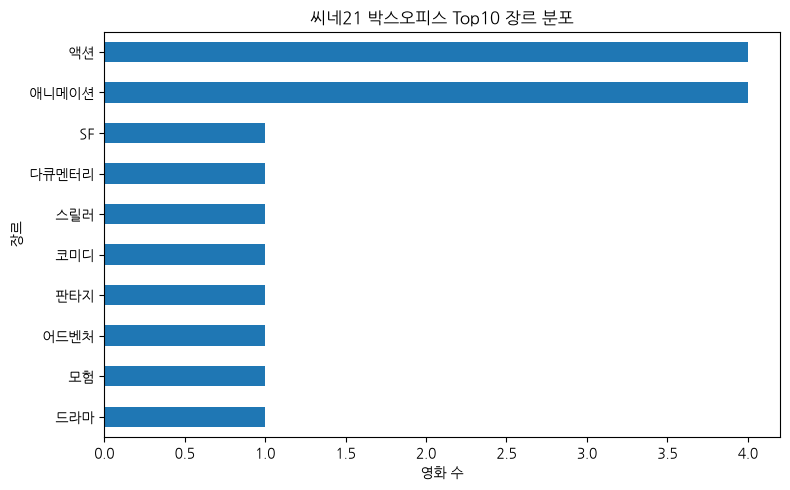

In [47]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

genre_count.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("씨네21 박스오피스 Top10 장르 분포")
plt.xlabel("영화 수")
plt.ylabel("장르")
plt.tight_layout()
plt.show()

#### 장르 분포 결과

상세 장르 정보가 확인된 9편을 기준으로 분석한 결과,
**액션과 애니메이션이 각각 4편으로 가장 많이 나타났다.**

액션 영화에는 모험·드라마·코미디·스릴러·SF 등 다른 장르가 함께 결합된 경우가 많았으며,
애니메이션은 단일 장르로 분류된 작품이 상대적으로 많이 확인되었다.

다만 한 영화가 여러 장르에 중복 집계될 수 있고,
1편은 상세페이지가 제공되지 않아 장르 정보가 결측되어 있으므로
각 장르 빈도의 합은 전체 영화 수와 일치하지 않는다.

#### 2) 관람등급 분포

박스오피스 상위 영화의 관람등급 분포를 확인하여
현재 흥행작이 어떤 관객층을 대상으로 구성되어 있는지 살펴본다.

In [48]:
rating_count = cine21_movies["rating"].value_counts()

rating_count

rating
15세이상관람가    3
12세이상관람가    3
전체 관람가      3
Name: count, dtype: int64

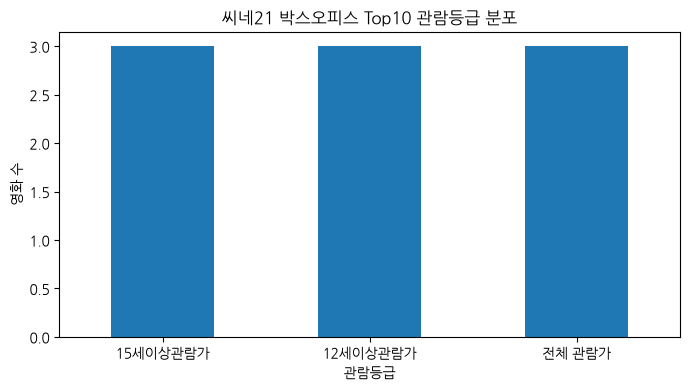

In [49]:
rating_count.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("씨네21 박스오피스 Top10 관람등급 분포")
plt.xlabel("관람등급")
plt.ylabel("영화 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 관람등급 분포 결과

상세정보가 확인된 9편의 관람등급을 비교한 결과,
**전체 관람가, 12세이상관람가, 15세이상관람가가 각각 3편씩 동일하게 나타났다.**

따라서 현재 박스오피스 상위권은 특정 연령층만을 대상으로 한 영화에 집중되어 있기보다,
아동·가족 관객부터 청소년 및 성인 관객까지 서로 다른 관객층을 대상으로 한 작품이 함께 구성되어 있음을 확인할 수 있다.

다만 1편은 상세페이지가 제공되지 않아 관람등급 정보가 결측되어 있으므로,
해당 결과는 관람등급이 확인된 9편을 기준으로 해석하였다.

#### 3) 국가 분포

박스오피스 상위 영화의 제작 국가 분포를 확인하여
현재 상위권 영화가 국내 작품과 해외 작품 중 어떻게 구성되어 있는지 살펴본다.

In [50]:
country_count = cine21_movies["country"].value_counts()

country_count

country
미국    4
한국    3
일본    2
Name: count, dtype: int64

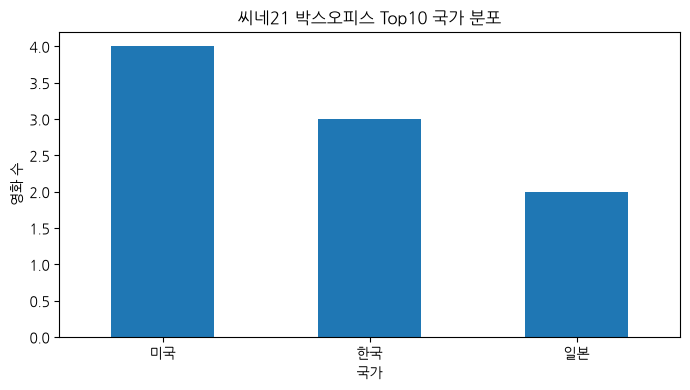

In [51]:
country_count.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("씨네21 박스오피스 Top10 국가 분포")
plt.xlabel("국가")
plt.ylabel("영화 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 국가 분포 결과

상세정보가 확인된 9편의 제작 국가를 비교한 결과,
**미국 영화가 4편으로 가장 많았으며, 한국 3편, 일본 2편 순으로 나타났다.**

현재 박스오피스 상위권에는 국내 영화뿐 아니라 미국과 일본 작품도 함께 포함되어 있어,
특정 국가의 작품만으로 구성되기보다 국내외 작품이 혼재된 모습을 보였다.

다만 1편은 상세페이지가 제공되지 않아 국가 정보가 결측되어 있으므로,
해당 결과는 국가 정보가 확인된 9편을 기준으로 해석하였다.

#### Q1. 분석 결과 요약

현재 씨네21 박스오피스 상위 영화의 작품 특성을 살펴본 결과,
장르 측면에서는 **액션과 애니메이션이 각각 4편으로 가장 많이 나타났으며**,
관람등급은 **전체 관람가·12세이상관람가·15세이상관람가가 각각 3편씩 동일하게 분포**하였다.

국가별로는 **미국 4편, 한국 3편, 일본 2편**으로 미국 작품이 가장 많았지만,
국내외 여러 국가의 작품이 함께 상위권을 구성하고 있었다.

종합하면 현재 박스오피스 상위권은 특정 관람등급이나 국가에 크게 집중되어 있기보다
다양한 관객층과 국가의 작품이 함께 구성되어 있으며,
장르에서는 액션과 애니메이션의 비중이 상대적으로 두드러졌다.

단, 상세페이지가 제공되지 않은 영화 1편의 작품 특성 정보가 결측되어 있어
본 결과는 상세정보가 확인된 9편을 중심으로 해석하였다.

### Q2. 전문가 평점이 높은 영화일수록 실제 흥행 성과도 높은가?

씨네21 전문가 리뷰는 한 영화에 여러 명의 평론가 평가가 존재하므로,
먼저 영화별 전문가 평균 평점을 계산한다.

이후 KOBIS의 최근 14일 박스오피스 데이터와 연결하여
전문가 평가와 실제 관객 성과가 함께 움직이는지 확인한다.

In [53]:
critic_summary = (
    critic_reviews
    .groupby(["movie_id", "title"])
    .agg(
        critic_mean_score=("critic_score", "mean"),
        critic_count=("critic_score", "count")
    )
    .reset_index()
)

critic_summary

,movie_id,title,critic_mean_score,critic_count
0,62480,호프,6.833333,6
1,62585,오디세이,7.545455,11
2,63075,사랑의 하츄핑: 고래보석의 전설,7.000000,1
3,63091,스파이더맨: 브랜드 뉴 데이,7.333333,9
4,63108,다윗,5.000000,1
5,63117,퍼피 구조대: 더 다이노 무비,5.000000,2
6,63240,오케이 마담2,5.600000,5
7,63245,명탐정 코난: 하이웨이의 타천사,6.000000,3
8,63282,어떻게 해야 했을까?,6.500000,4


In [54]:
score_check = (
    cine21_movies[
        ["movie_id", "title", "cine21_score"]
    ]
    .merge(
        critic_summary,
        on=["movie_id", "title"],
        how="inner"
    )
)

score_check["score_diff"] = (
    score_check["cine21_score"]
    - score_check["critic_mean_score"]
).abs()

score_check

,movie_id,title,cine21_score,critic_mean_score,critic_count,score_diff
0,62585,오디세이,7.55,7.545455,11,0.004545
1,63091,스파이더맨: 브랜드 뉴 데이,7.33,7.333333,9,0.003333
2,63075,사랑의 하츄핑: 고래보석의 전설,7.00,7.000000,1,0.000000
3,63245,명탐정 코난: 하이웨이의 타천사,6.00,6.000000,3,0.000000
4,63240,오케이 마담2,5.60,5.600000,5,0.000000
5,63117,퍼피 구조대: 더 다이노 무비,5.00,5.000000,2,0.000000
6,62480,호프,6.83,6.833333,6,0.003333
7,63282,어떻게 해야 했을까?,6.50,6.500000,4,0.000000
8,63108,다윗,5.00,5.000000,1,0.000000


#### 전문가 평점 변수 확인

씨네21 메인 페이지의 평점과 상세페이지에서 직접 계산한 전문가 평균 평점을 비교한 결과,
두 값의 최대 차이는 약 0.005점으로 사실상 동일하게 나타났다.

따라서 두 변수를 별개의 평가 지표로 사용하지 않고,
이후 분석에서는 개별 전문가 별점을 직접 평균한 `critic_mean_score`를 대표 전문가 평점으로 사용한다.

또한 영화별 평가에 참여한 전문가 수가 1명에서 11명까지 차이가 있으므로,
평균 평점 해석 시 평가 참여 인원도 함께 고려한다.

In [55]:
kobis_movie_summary = (
    kobis_14d[
        kobis_14d["movieNm"].isin(common_titles)
    ]
    .groupby(["movieCd", "movieNm"])
    .agg(
        period_audience=("audiCnt", "sum"),
        max_audience_acc=("audiAcc", "max"),
        top10_days=("date", "nunique"),
        avg_rank=("rank", "mean")
    )
    .reset_index()
)

kobis_movie_summary

,movieCd,movieNm,period_audience,max_audience_acc,top10_days,avg_rank
0,20233219,호프,589789,4446016,14,3.857143
1,20250654,오디세이,3179132,3179756,12,2.416667
2,20255484,오케이 마담2,105594,109224,6,6.166667
3,20262381,사랑의 하츄핑: 고래보석의 전설,508520,514028,13,4.384615
4,20262770,스파이더맨: 브랜드 뉴 데이,5006052,6666457,14,1.714286
5,20262902,다윗,46635,291272,11,7.272727
6,20262945,퍼피 구조대: 더 다이노 무비,8493,11493,3,8.000000
7,20264148,어떻게 해야 했을까?,49928,62278,14,6.928571
8,20264635,명탐정 코난: 하이웨이의 타천사,138310,138310,5,4.800000


In [56]:
q2_df = critic_summary.merge(
    kobis_movie_summary,
    left_on="title",
    right_on="movieNm",
    how="inner"
)

q2_df = q2_df[
    [
        "title",
        "critic_mean_score",
        "critic_count",
        "period_audience",
        "max_audience_acc",
        "top10_days",
        "avg_rank"
    ]
]

q2_df

,title,critic_mean_score,critic_count,period_audience,max_audience_acc,top10_days,avg_rank
0,호프,6.833333,6,589789,4446016,14,3.857143
1,오디세이,7.545455,11,3179132,3179756,12,2.416667
2,사랑의 하츄핑: 고래보석의 전설,7.000000,1,508520,514028,13,4.384615
3,스파이더맨: 브랜드 뉴 데이,7.333333,9,5006052,6666457,14,1.714286
4,다윗,5.000000,1,46635,291272,11,7.272727
5,퍼피 구조대: 더 다이노 무비,5.000000,2,8493,11493,3,8.000000
6,오케이 마담2,5.600000,5,105594,109224,6,6.166667
7,명탐정 코난: 하이웨이의 타천사,6.000000,3,138310,138310,5,4.800000
8,어떻게 해야 했을까?,6.500000,4,49928,62278,14,6.928571


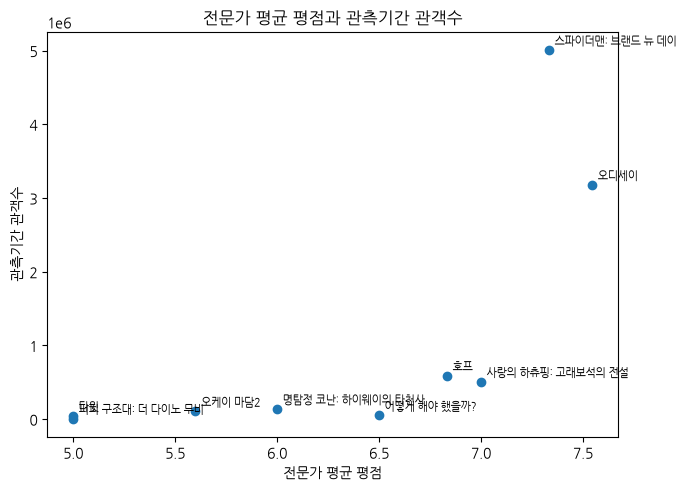

In [57]:
plt.figure(figsize=(7, 5))

plt.scatter(
    q2_df["critic_mean_score"],
    q2_df["period_audience"]
)

for _, row in q2_df.iterrows():
    plt.annotate(
        row["title"],
        (row["critic_mean_score"], row["period_audience"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("전문가 평균 평점과 관측기간 관객수")
plt.xlabel("전문가 평균 평점")
plt.ylabel("관측기간 관객수")
plt.tight_layout()
plt.show()

In [58]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    q2_df["critic_mean_score"],
    q2_df["period_audience"]
)

spearman_r, spearman_p = spearmanr(
    q2_df["critic_mean_score"],
    q2_df["period_audience"]
)

print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman ρ: {spearman_r:.3f}, p-value: {spearman_p:.4f}")

Pearson r: 0.692, p-value: 0.0387
Spearman ρ: 0.912, p-value: 0.0006


In [59]:
q2_df["avg_daily_audience"] = (
    q2_df["period_audience"]
    / q2_df["top10_days"]
)

q2_df[
    [
        "title",
        "critic_mean_score",
        "top10_days",
        "period_audience",
        "avg_daily_audience"
    ]
].sort_values(
    "avg_daily_audience",
    ascending=False
)

,title,critic_mean_score,top10_days,period_audience,avg_daily_audience
3,스파이더맨: 브랜드 뉴 데이,7.333333,14,5006052,357575.142857
1,오디세이,7.545455,12,3179132,264927.666667
0,호프,6.833333,14,589789,42127.785714
2,사랑의 하츄핑: 고래보석의 전설,7.000000,13,508520,39116.923077
7,명탐정 코난: 하이웨이의 타천사,6.000000,5,138310,27662.000000
6,오케이 마담2,5.600000,6,105594,17599.000000
4,다윗,5.000000,11,46635,4239.545455
8,어떻게 해야 했을까?,6.500000,14,49928,3566.285714
5,퍼피 구조대: 더 다이노 무비,5.000000,3,8493,2831.000000


In [60]:
pearson_avg_r, pearson_avg_p = pearsonr(
    q2_df["critic_mean_score"],
    q2_df["avg_daily_audience"]
)

spearman_avg_r, spearman_avg_p = spearmanr(
    q2_df["critic_mean_score"],
    q2_df["avg_daily_audience"]
)

print(
    f"Pearson r: {pearson_avg_r:.3f}, "
    f"p-value: {pearson_avg_p:.4f}"
)

print(
    f"Spearman ρ: {spearman_avg_r:.3f}, "
    f"p-value: {spearman_avg_p:.4f}"
)

Pearson r: 0.703, p-value: 0.0347
Spearman ρ: 0.854, p-value: 0.0034


In [61]:
pearson_acc_r, pearson_acc_p = pearsonr(
    q2_df["critic_mean_score"],
    q2_df["max_audience_acc"]
)

spearman_acc_r, spearman_acc_p = spearmanr(
    q2_df["critic_mean_score"],
    q2_df["max_audience_acc"]
)

print(
    f"Pearson r: {pearson_acc_r:.3f}, "
    f"p-value: {pearson_acc_p:.4f}"
)

print(
    f"Spearman ρ: {spearman_acc_r:.3f}, "
    f"p-value: {spearman_acc_p:.4f}"
)

Pearson r: 0.682, p-value: 0.0429
Spearman ρ: 0.736, p-value: 0.0237


#### Q2. 분석 결과

씨네21과 KOBIS에 공통으로 포함된 9편을 대상으로 전문가 평균 평점과 흥행 성과의 관계를 확인하였다.

먼저 최근 14일의 KOBIS Top10 관측기간 관객수와 전문가 평점을 비교한 결과,
Pearson 상관계수는 **0.692(p=0.0387)**,
Spearman 순위상관계수는 **0.912(p=0.0006)**로 나타났다.

영화마다 Top10에 등장한 기간이 서로 다른 점을 고려하여
Top10 등장일 기준 일평균 관객수로 보정한 경우에도
Pearson **0.703(p=0.0347)**,
Spearman **0.854(p=0.0034)**의 양의 관계가 유지되었다.

최대 누적 관객수를 기준으로 비교했을 때도
Pearson **0.682(p=0.0429)**,
Spearman **0.736(p=0.0237)**로 양의 관계가 나타났다.

따라서 현재 분석 대상에서는 **전문가 평가가 높은 영화일수록 흥행 성과도 높은 경향**이 일관되게 관찰되었다.
특히 관측기간 관객수의 순위와 전문가 평점 순위 사이의 관계가 강하게 나타났다.

다만 분석 대상이 9편으로 적고, 이미 박스오피스 상위권에 진입한 영화만을 대상으로 한 결과이므로
이를 전체 영화에 일반화하거나 전문가 평가가 흥행을 직접적으로 높였다고 해석하기는 어렵다.
또한 영화별 전문가 평가 참여 인원이 1명에서 11명까지 차이가 있다는 점도 함께 고려할 필요가 있다.

### Q3. 흥행 성과는 상영 기회와 관객 동원력 중 무엇과 더 관련이 있는가?

영화의 관객수가 많은 이유는 많은 스크린과 상영 횟수를 확보했기 때문일 수도 있고,
동일한 상영 기회에서도 더 많은 관객을 끌어들였기 때문일 수도 있다.

따라서 최근 14일의 KOBIS 데이터를 영화 단위로 집계하여
관객수와 상영 횟수·스크린 노출량의 관계를 확인하고,
상영 1회당 관객수와 스크린-일당 관객수 등의 효율 지표를 함께 비교한다.

In [62]:
q3_df = (
    kobis_14d
    .groupby(["movieCd", "movieNm"])
    .agg(
        period_audience=("audiCnt", "sum"),
        period_show_count=("showCnt", "sum"),
        screen_days=("scrnCnt", "sum"),
        top10_days=("date", "nunique")
    )
    .reset_index()
)

q3_df["audience_per_show"] = (
    q3_df["period_audience"]
    / q3_df["period_show_count"]
)

q3_df["audience_per_screen_day"] = (
    q3_df["period_audience"]
    / q3_df["screen_days"]
)

q3_df.sort_values(
    "period_audience",
    ascending=False
)

,movieCd,movieNm,period_audience,period_show_count,screen_days,top10_days,audience_per_show,audience_per_screen_day
11,20262770,스파이더맨: 브랜드 뉴 데이,5006052,91041,25259,14,54.986786,198.188844
5,20250654,오디세이,3179132,50430,17196,12,63.040492,184.876250
2,20233219,호프,589789,19084,8969,14,30.904894,65.758613
10,20262381,사랑의 하츄핑: 고래보석의 전설,508520,15164,7672,13,33.534687,66.282586
16,20264635,명탐정 코난: 하이웨이의 타천사,138310,4908,2351,5,28.180522,58.830285
6,20255484,오케이 마담2,105594,7074,2675,6,14.927057,39.474393
9,20261784,미니언즈 & 몬스터즈,102127,6215,4588,13,16.432341,22.259590
7,20259781,토이 스토리 5,51634,2820,2388,11,18.309929,21.622278
15,20264148,어떻게 해야 했을까?,49928,1679,933,14,29.736748,53.513398
8,20259946,모아나,46767,2863,2245,9,16.334963,20.831626


In [63]:
q3_df["avg_daily_audience"] = (
    q3_df["period_audience"]
    / q3_df["top10_days"]
)

q3_df["avg_daily_show_count"] = (
    q3_df["period_show_count"]
    / q3_df["top10_days"]
)

q3_df["avg_daily_screen_count"] = (
    q3_df["screen_days"]
    / q3_df["top10_days"]
)

q3_df[
    [
        "movieNm",
        "top10_days",
        "avg_daily_audience",
        "avg_daily_show_count",
        "avg_daily_screen_count",
        "audience_per_show"
    ]
].sort_values(
    "avg_daily_audience",
    ascending=False
)

,movieNm,top10_days,avg_daily_audience,avg_daily_show_count,avg_daily_screen_count,audience_per_show
11,스파이더맨: 브랜드 뉴 데이,14,357575.142857,6502.928571,1804.214286,54.986786
5,오디세이,12,264927.666667,4202.500000,1433.000000,63.040492
2,호프,14,42127.785714,1363.142857,640.642857,30.904894
10,사랑의 하츄핑: 고래보석의 전설,13,39116.923077,1166.461538,590.153846,33.534687
16,명탐정 코난: 하이웨이의 타천사,5,27662.000000,981.600000,470.200000,28.180522
6,오케이 마담2,6,17599.000000,1179.000000,445.833333,14.927057
9,미니언즈 & 몬스터즈,13,7855.923077,478.076923,352.923077,16.432341
8,모아나,9,5196.333333,318.111111,249.444444,16.334963
7,토이 스토리 5,11,4694.000000,256.363636,217.090909,18.309929
12,다윗,11,4239.545455,147.454545,133.272727,28.751541


In [64]:
# 하루 평균 관객수 vs 하루 평균 상영횟수
show_pearson_r, show_pearson_p = pearsonr(
    q3_df["avg_daily_audience"],
    q3_df["avg_daily_show_count"]
)

show_spearman_r, show_spearman_p = spearmanr(
    q3_df["avg_daily_audience"],
    q3_df["avg_daily_show_count"]
)

# 하루 평균 관객수 vs 하루 평균 스크린 수
screen_pearson_r, screen_pearson_p = pearsonr(
    q3_df["avg_daily_audience"],
    q3_df["avg_daily_screen_count"]
)

screen_spearman_r, screen_spearman_p = spearmanr(
    q3_df["avg_daily_audience"],
    q3_df["avg_daily_screen_count"]
)

print("[평균 관객수 vs 평균 상영횟수]")
print(
    f"Pearson r: {show_pearson_r:.3f}, "
    f"p-value: {show_pearson_p:.4f}"
)
print(
    f"Spearman ρ: {show_spearman_r:.3f}, "
    f"p-value: {show_spearman_p:.4f}"
)

print("\n[평균 관객수 vs 평균 스크린 수]")
print(
    f"Pearson r: {screen_pearson_r:.3f}, "
    f"p-value: {screen_pearson_p:.4f}"
)
print(
    f"Spearman ρ: {screen_spearman_r:.3f}, "
    f"p-value: {screen_spearman_p:.4f}"
)

[평균 관객수 vs 평균 상영횟수]
Pearson r: 0.986, p-value: 0.0000
Spearman ρ: 0.890, p-value: 0.0000

[평균 관객수 vs 평균 스크린 수]
Pearson r: 0.955, p-value: 0.0000
Spearman ρ: 0.920, p-value: 0.0000


#### 상영 기회와 관객수의 관계

Top10 등장일을 기준으로 하루 평균값을 비교한 결과,
평균 관객수와 평균 상영횟수 사이에는 Pearson **0.986**, Spearman **0.890**의 강한 양의 관계가 나타났다.

평균 스크린 수와 평균 관객수 역시 Pearson **0.955**, Spearman **0.920**으로 높은 양의 관계를 보였다.
따라서 최근 박스오피스에서는 관객수가 많은 영화일수록 더 많은 스크린과 상영 기회를 확보하는 패턴이 뚜렷하게 나타났다.

다만 이는 상영 기회가 관객수를 증가시켰다는 인과관계를 의미하지 않는다.
흥행 수요가 높은 영화에 극장이 더 많은 스크린과 상영 횟수를 배정했을 가능성도 있으므로,
본 결과는 상영 기회와 흥행 규모가 강하게 함께 움직인다는 관계로 해석한다.

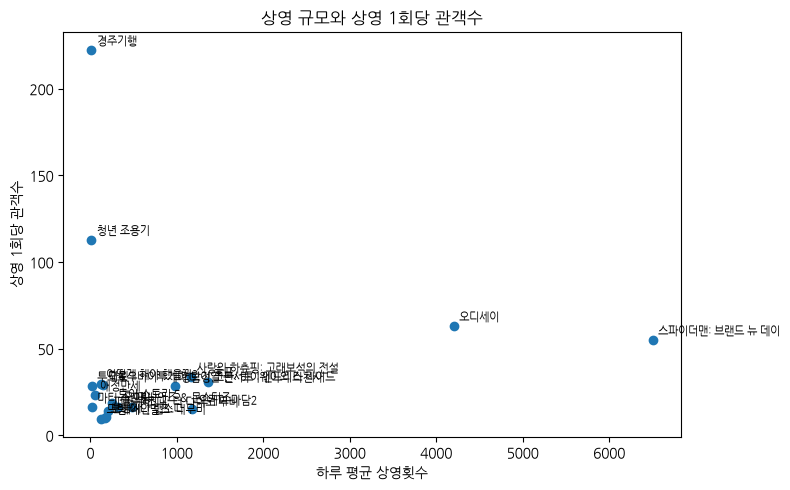

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q3_df["avg_daily_show_count"],
    q3_df["audience_per_show"]
)

for _, row in q3_df.iterrows():
    plt.annotate(
        row["movieNm"],
        (
            row["avg_daily_show_count"],
            row["audience_per_show"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("상영 규모와 상영 1회당 관객수")
plt.xlabel("하루 평균 상영횟수")
plt.ylabel("상영 1회당 관객수")
plt.tight_layout()
plt.show()

In [66]:
show_threshold = q3_df["period_show_count"].median()

stable_q3 = q3_df[
    q3_df["period_show_count"] >= show_threshold
].copy()

print("상영횟수 중앙값:", show_threshold)
print("분석 영화 수:", len(stable_q3))

stable_q3[
    [
        "movieNm",
        "period_show_count",
        "period_audience",
        "audience_per_show"
    ]
].sort_values(
    "audience_per_show",
    ascending=False
)

상영횟수 중앙값: 1650.5
분석 영화 수: 10


,movieNm,period_show_count,period_audience,audience_per_show
5,오디세이,50430,3179132,63.040492
11,스파이더맨: 브랜드 뉴 데이,91041,5006052,54.986786
10,사랑의 하츄핑: 고래보석의 전설,15164,508520,33.534687
2,호프,19084,589789,30.904894
15,어떻게 해야 했을까?,1679,49928,29.736748
16,명탐정 코난: 하이웨이의 타천사,4908,138310,28.180522
7,토이 스토리 5,2820,51634,18.309929
9,미니언즈 & 몬스터즈,6215,102127,16.432341
8,모아나,2863,46767,16.334963
6,오케이 마담2,7074,105594,14.927057


In [67]:
stable_q3["shows_per_screen_day"] = (
    stable_q3["period_show_count"]
    / stable_q3["screen_days"]
)

stable_q3[
    [
        "movieNm",
        "period_audience",
        "audience_per_show",
        "audience_per_screen_day",
        "shows_per_screen_day"
    ]
].sort_values(
    "period_audience",
    ascending=False
)

,movieNm,period_audience,audience_per_show,audience_per_screen_day,shows_per_screen_day
11,스파이더맨: 브랜드 뉴 데이,5006052,54.986786,198.188844,3.604299
5,오디세이,3179132,63.040492,184.876250,2.932659
2,호프,589789,30.904894,65.758613,2.127773
10,사랑의 하츄핑: 고래보석의 전설,508520,33.534687,66.282586,1.976538
16,명탐정 코난: 하이웨이의 타천사,138310,28.180522,58.830285,2.087622
6,오케이 마담2,105594,14.927057,39.474393,2.644486
9,미니언즈 & 몬스터즈,102127,16.432341,22.259590,1.354621
7,토이 스토리 5,51634,18.309929,21.622278,1.180905
15,어떻게 해야 했을까?,49928,29.736748,53.513398,1.799571
8,모아나,46767,16.334963,20.831626,1.275278


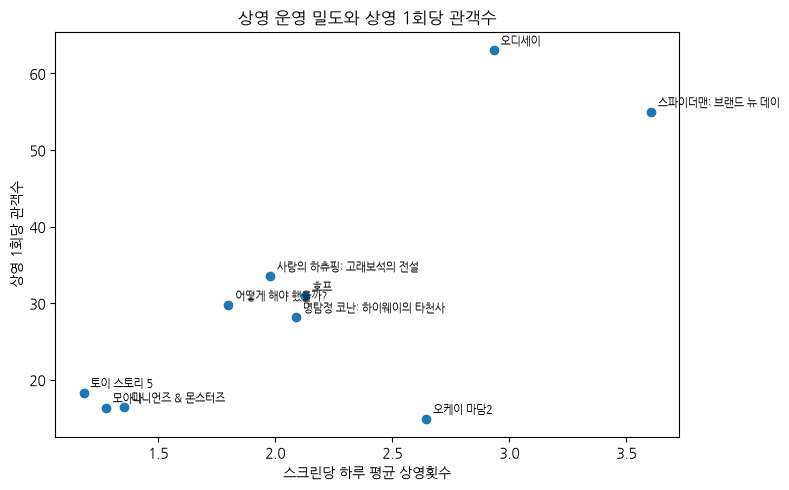

In [68]:
plt.figure(figsize=(8, 5))

plt.scatter(
    stable_q3["shows_per_screen_day"],
    stable_q3["audience_per_show"]
)

for _, row in stable_q3.iterrows():
    plt.annotate(
        row["movieNm"],
        (
            row["shows_per_screen_day"],
            row["audience_per_show"]
        ),
        fontsize=8,
        xytext=(5, 4),
        textcoords="offset points"
    )

plt.title("상영 운영 밀도와 상영 1회당 관객수")
plt.xlabel("스크린당 하루 평균 상영횟수")
plt.ylabel("상영 1회당 관객수")
plt.tight_layout()
plt.show()

#### Q3. 분석 결과

최근 14일 KOBIS Top10 영화의 상영 기회와 관객수 관계를 분석한 결과,
Top10 등장일 기준 하루 평균 관객수와 하루 평균 상영횟수 사이에는
Pearson **0.986**, Spearman **0.890**의 강한 양의 관계가 나타났다.

하루 평균 스크린 수와 평균 관객수 역시
Pearson **0.955**, Spearman **0.920**으로 높은 양의 관계를 보였다.

따라서 최근 박스오피스에서는 **관객수가 많은 영화일수록 더 많은 스크린과 상영 기회를 확보하는 패턴**이 매우 강하게 나타났다.
다만 이는 상영 기회가 관객수를 증가시켰다는 인과관계를 의미하지 않으며,
높은 관객 수요에 따라 극장이 더 많은 상영 기회를 배정했을 가능성도 함께 존재한다.

한편 상영 기회 대비 관객 동원력을 확인하기 위해 상영 1회당 관객수를 비교한 결과,
상영량이 매우 적은 일부 영화에서는 작은 분모로 인해 효율 지표가 과도하게 커지는 현상이 확인되었다.
이에 전체 영화의 기간 상영횟수 중앙값 이상인 10편을 별도로 비교하였다.

그 결과 **오디세이는 상영 1회당 약 63.0명으로 스파이더맨의 약 55.0명보다 높은 회차당 관객 동원력**을 보였다.
반면 스파이더맨은 스크린당 하루 평균 약 3.60회를 상영하여
오디세이의 약 2.93회보다 높은 운영 밀도를 보였고,
스크린-일당 관객수 역시 약 198.2명으로 오디세이의 약 184.9명보다 높았다.

즉, **흥행 규모는 상영 기회와 매우 강하게 연결되어 있었지만,
동일한 상영 기회를 실제 관객으로 전환하는 효율과 스크린 운영 방식은 영화마다 차이가 있었다.**

### Q4. 최근 박스오피스 관객수에는 요일에 따른 패턴이 나타나는가?

최근 14일의 KOBIS 일별 Top10 데이터를 날짜 단위로 집계하여
전체 관객수의 흐름과 요일별 차이를 확인한다.

영화별 관객수를 단순 비교하는 것이 아니라,
각 날짜의 Top10 영화 관객수를 합산하여 해당 날짜의 박스오피스 관객 규모를 살펴본다.

In [69]:
daily_summary = (
    kobis_14d
    .groupby("date")
    .agg(
        total_audience=("audiCnt", "sum"),
        total_sales=("salesAmt", "sum"),
        total_show_count=("showCnt", "sum")
    )
    .reset_index()
)

daily_summary

,date,total_audience,total_sales,total_show_count
0,2026-08-01,1112549,11854655910,15855
1,2026-08-02,1020981,10752906610,15319
2,2026-08-03,501845,5132327820,14150
3,2026-08-04,446006,4556205250,14168
4,2026-08-05,687751,6962511250,14454
5,2026-08-06,573594,5853371410,14277
6,2026-08-07,684668,7349538160,14796
7,2026-08-08,1225215,12913829230,15390
8,2026-08-09,1143333,11977435390,14854
9,2026-08-10,473848,4994435400,13585


In [70]:
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

daily_summary["weekday"] = (
    daily_summary["date"]
    .dt.dayofweek
    .map(weekday_map)
)

daily_summary["is_weekend"] = (
    daily_summary["date"]
    .dt.dayofweek
    .isin([5, 6])
)

daily_summary[
    ["date", "weekday", "total_audience", "is_weekend"]
]

,date,weekday,total_audience,is_weekend
0,2026-08-01,토,1112549,True
1,2026-08-02,일,1020981,True
2,2026-08-03,월,501845,False
3,2026-08-04,화,446006,False
4,2026-08-05,수,687751,False
5,2026-08-06,목,573594,False
6,2026-08-07,금,684668,False
7,2026-08-08,토,1225215,True
8,2026-08-09,일,1143333,True
9,2026-08-10,월,473848,False


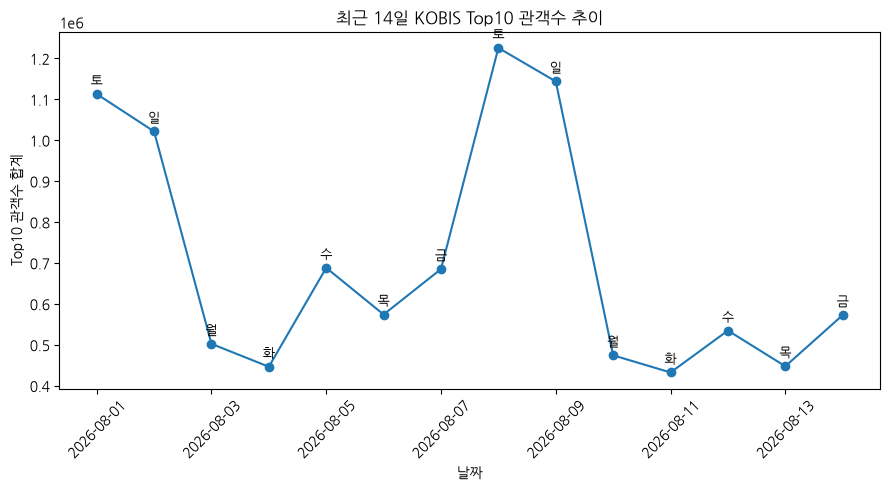

In [71]:
plt.figure(figsize=(9, 5))

plt.plot(
    daily_summary["date"],
    daily_summary["total_audience"],
    marker="o"
)

for _, row in daily_summary.iterrows():
    plt.annotate(
        row["weekday"],
        (row["date"], row["total_audience"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.title("최근 14일 KOBIS Top10 관객수 추이")
plt.xlabel("날짜")
plt.ylabel("Top10 관객수 합계")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
weekend_compare = (
    daily_summary
    .groupby("is_weekend")
    .agg(
        avg_audience=("total_audience", "mean"),
        avg_sales=("total_sales", "mean"),
        avg_show_count=("total_show_count", "mean"),
        days=("date", "count")
    )
)

weekend_compare.index = [
    "평일" if not x else "주말"
    for x in weekend_compare.index
]

weekend_compare

,avg_audience,avg_sales,avg_show_count,days
평일,535336.3,5.567583e+09,14366.8,10
주말,1125519.5,1.187471e+10,15354.5,4


In [73]:
weekday_avg = weekend_compare.loc["평일", "avg_audience"]
weekend_avg = weekend_compare.loc["주말", "avg_audience"]

weekend_ratio = weekend_avg / weekday_avg

print(f"평일 평균 관객수: {weekday_avg:,.0f}명")
print(f"주말 평균 관객수: {weekend_avg:,.0f}명")
print(f"주말 / 평일 관객수 배율: {weekend_ratio:.2f}배")

평일 평균 관객수: 535,336명
주말 평균 관객수: 1,125,520명
주말 / 평일 관객수 배율: 2.10배


In [74]:
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

weekday_summary = (
    daily_summary
    .groupby("weekday")
    .agg(
        avg_audience=("total_audience", "mean"),
        avg_show_count=("total_show_count", "mean"),
        days=("date", "count")
    )
    .reindex(weekday_order)
)

weekday_summary

,avg_audience,avg_show_count,days
weekday,,,
월,487846.5,13867.5,2
화,438992.0,13956.0,2
수,611077.5,14632.5,2
목,510350.0,14383.5,2
금,628415.5,14994.5,2
토,1168882.0,15622.5,2
일,1082157.0,15086.5,2


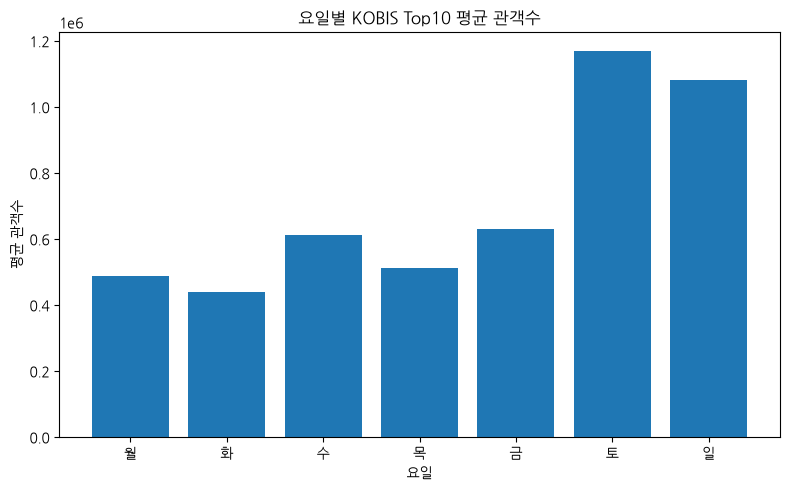

In [75]:
plt.figure(figsize=(8, 5))

plt.bar(
    weekday_summary.index,
    weekday_summary["avg_audience"]
)

plt.title("요일별 KOBIS Top10 평균 관객수")
plt.xlabel("요일")
plt.ylabel("평균 관객수")

plt.tight_layout()
plt.show()

In [76]:
daily_summary["audience_per_show"] = (
    daily_summary["total_audience"]
    / daily_summary["total_show_count"]
)

weekday_efficiency = (
    daily_summary
    .groupby("weekday")
    .agg(
        avg_audience_per_show=("audience_per_show", "mean")
    )
    .reindex(weekday_order)
)

weekday_efficiency

,avg_audience_per_show
weekday,
월,35.173157
화,31.455055
수,41.831807
목,35.516132
금,41.966752
토,74.890671
일,71.809703


In [77]:
weekend_efficiency = (
    daily_summary
    .groupby("is_weekend")
    .agg(
        avg_audience=("total_audience", "mean"),
        avg_show_count=("total_show_count", "mean"),
        avg_audience_per_show=("audience_per_show", "mean")
    )
)

weekend_efficiency.index = [
    "평일" if not x else "주말"
    for x in weekend_efficiency.index
]

audience_ratio = (
    weekend_efficiency.loc["주말", "avg_audience"]
    / weekend_efficiency.loc["평일", "avg_audience"]
)

show_ratio = (
    weekend_efficiency.loc["주말", "avg_show_count"]
    / weekend_efficiency.loc["평일", "avg_show_count"]
)

efficiency_ratio = (
    weekend_efficiency.loc["주말", "avg_audience_per_show"]
    / weekend_efficiency.loc["평일", "avg_audience_per_show"]
)

display(weekend_efficiency)

print(f"주말 / 평일 관객수: {audience_ratio:.2f}배")
print(f"주말 / 평일 상영횟수: {show_ratio:.2f}배")
print(f"주말 / 평일 상영 1회당 관객수: {efficiency_ratio:.2f}배")

,avg_audience,avg_show_count,avg_audience_per_show
평일,535336.3,14366.8,37.188581
주말,1125519.5,15354.5,73.350187


주말 / 평일 관객수: 2.10배
주말 / 평일 상영횟수: 1.07배
주말 / 평일 상영 1회당 관객수: 1.97배


#### Q4. 분석 결과

최근 14일의 KOBIS 일별 Top10 관객수를 날짜별로 집계한 결과,
두 주 모두 **토요일과 일요일에 관객수가 크게 증가하고 월·화요일에 감소하는 반복적인 패턴**이 나타났다.

요일별 평균 관객수는 토요일이 약 **116.9만 명**으로 가장 높았고,
일요일이 약 **108.2만 명**으로 뒤를 이었다.
반면 화요일은 약 **43.9만 명**으로 가장 낮았다.

평일과 주말을 비교하면,
주말 평균 관객수는 약 **112.6만 명**으로 평일 약 **53.5만 명**의 **2.10배**였다.

그러나 평균 상영횟수는 주말이 평일의 **1.07배**에 그쳤다.
반면 상영 1회당 평균 관객수는 평일 약 **37.2명**에서
주말 약 **73.4명**으로 증가하여 **1.97배** 수준으로 나타났다.

따라서 이번 관측기간의 주말 관객 증가에는
단순한 상영횟수 확대보다 **각 상영 회차의 관객 밀도가 크게 높아진 패턴**이 더 두드러졌다.

다만 본 분석은 2주간의 데이터만을 대상으로 하므로
이를 장기적인 계절성으로 일반화하기는 어렵다.
공휴일, 개봉 일정, 특정 흥행작의 영향도 함께 작용할 수 있으므로
더 긴 기간의 데이터를 확보한다면 요일 효과를 추가로 검증할 필요가 있다.

## 5. 심화 분석

### 5.1 전문가 20자평 텍스트 분석

씨네21에서 수집한 42건의 전문가 20자평을 활용하여
평론가들이 현재 박스오피스 상위 영화들을 어떤 표현과 관점으로 평가했는지 살펴본다.

먼저 텍스트를 정제하고 주요 단어의 출현 빈도를 확인한 뒤,
TF-IDF를 활용하여 단순히 자주 등장하는 단어가 아니라
각 영화의 평가에서 상대적으로 특징적인 키워드를 탐색한다.

In [78]:
critic_reviews[
    ["title", "critic_score", "review"]
].head(10)

,title,critic_score,review
0,오디세이,8.0,그리스신화는 놀런을 만나길 오랫동안 기다려왔구나
1,오디세이,8.0,늘 해오던 걸 가장 잘 할 수 있는 방식으로
2,오디세이,7.0,죽음과 죄책감을 등에 업은 영웅의 서사
3,오디세이,7.0,좋으나 싫으나 미우나 고우나 크리스토퍼 놀런의 여름 블록버스터
4,오디세이,6.0,"원전과 어긋나는 놀런의 속도, 이 어긋남을 적절히 조율하려는 음악"
5,오디세이,7.0,야심가다운 변용과 뚝심의 산문시
6,오디세이,9.0,거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다
7,오디세이,9.0,"놀런, 인간의 탈을 쓴 영화의 신"
8,오디세이,8.0,"어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역..."
9,오디세이,7.0,VFX와 핍진성 사이에서 펼쳐진 신화적 풍경


In [79]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

test_text = critic_reviews.loc[0, "review"]

print("원문:", test_text)
print("\n형태소 분석 결과:")

for token in kiwi.tokenize(test_text):
    print(token.form, token.tag)

원문: 그리스신화는 놀런을 만나길 오랫동안 기다려왔구나

형태소 분석 결과:
그리스 NNP
신화 NNG
는 JX
놀런 NNP
을 JKO
만나 VV
기 ETN
ᆯ JKO
오랫동안 NNG
기다리 VV
어 EC
오 VX
었 EP
구나 EF


#### 텍스트 전처리

전문가 20자평은 짧은 한국어 문장으로 구성되어 있어,
단순 띄어쓰기보다 형태소 단위 분석이 적합하다고 판단하였다.

Kiwi 형태소 분석기를 이용해 일반명사·고유명사·동사·형용사 및 영문 표현을 추출하고,
조사와 어미 등 문맥적 의미가 적은 형태소는 제외한다.

동사와 형용사는 활용형 차이를 줄이기 위해 기본형에 가까운 형태로 정규화한다.

In [ ]:
keep_tags = {
    "NNG",  # 일반명사
    "NNP",  # 고유명사
    "VV",   # 동사
    "VA",   # 형용사
    "SL"    # 영문
}

def tokenize_review(text):
    tokens = []

    for token in kiwi.tokenize(text):
        if token.tag not in keep_tags:
            continue

        word = token.form.strip()

        # 동사·형용사는 기본형 형태로 통일
        if token.tag in {"VV", "VA"}:
            word = word + "다"

        tokens.append(word)

    return tokens

In [81]:
critic_reviews["tokens"] = (
    critic_reviews["review"]
    .apply(tokenize_review)
)

critic_reviews[
    ["title", "critic_score", "review", "tokens"]
].head(10)

,title,critic_score,review,tokens
0,오디세이,8.0,그리스신화는 놀런을 만나길 오랫동안 기다려왔구나,"[그리스, 신화, 놀런, 만나다, 오랫동안, 기다리다]"
1,오디세이,8.0,늘 해오던 걸 가장 잘 할 수 있는 방식으로,"[하다, 하다, 있다, 방식]"
2,오디세이,7.0,죽음과 죄책감을 등에 업은 영웅의 서사,"[죽음, 죄책감, 등, 영웅, 서사]"
3,오디세이,7.0,좋으나 싫으나 미우나 고우나 크리스토퍼 놀런의 여름 블록버스터,"[좋다, 싫다, 크리스토퍼 놀런, 여름, 블록버스터]"
4,오디세이,6.0,"원전과 어긋나는 놀런의 속도, 이 어긋남을 적절히 조율하려는 음악","[원전, 어긋나다, 놀, 런, 속도, 어긋나다, 조율, 음악]"
5,오디세이,7.0,야심가다운 변용과 뚝심의 산문시,"[야심가, 변용, 뚝심, 산문시]"
6,오디세이,9.0,거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다,"[거대, 함선, 타다, 신화, 영화, 사이, 전속, 항해]"
7,오디세이,9.0,"놀런, 인간의 탈을 쓴 영화의 신","[놀다, 인간, 탈, 쓰다, 영화, 신]"
8,오디세이,8.0,"어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역...","[좋다, 어설프다, 가려내다, 역할, 하다]"
9,오디세이,7.0,VFX와 핍진성 사이에서 펼쳐진 신화적 풍경,"[VFX, 핍진, 사이, 펼쳐지다, 신화, 풍경]"


In [82]:
from collections import Counter

all_tokens = [
    token
    for tokens in critic_reviews["tokens"]
    for token in tokens
]

word_count = Counter(all_tokens)

word_freq = (
    pd.DataFrame(
        word_count.items(),
        columns=["word", "count"]
    )
    .sort_values(
        "count",
        ascending=False
    )
    .reset_index(drop=True)
)

word_freq.head(30)

,word,count
0,하다,4
1,영화,4
2,좋다,3
3,신화,3
4,성장,3
5,런,2
6,어긋나다,2
7,펼쳐지다,2
8,타다,2
9,사이,2


#### 불용어 제거

전체 토큰 빈도를 확인한 결과,
`하다`, `있다`, `영화`와 같이 여러 영화 리뷰에서 일반적으로 사용되며
작품별 특징을 구분하는 데 정보량이 낮은 표현이 확인되었다.

말뭉치가 42건으로 크지 않기 때문에 불용어를 과도하게 제거하지 않고,
분석 목적상 의미가 낮다고 판단되는 일부 표현만 최소한으로 제외하였다.

In [83]:
stopwords = {
    "하다",
    "있다",
    "영화",
    "등",
    "사이"
}

critic_reviews["clean_tokens"] = (
    critic_reviews["tokens"]
    .apply(
        lambda tokens: [
            token
            for token in tokens
            if token not in stopwords
        ]
    )
)

critic_reviews[
    ["title", "review", "tokens", "clean_tokens"]
].head(10)

,title,review,tokens,clean_tokens
0,오디세이,그리스신화는 놀런을 만나길 오랫동안 기다려왔구나,"[그리스, 신화, 놀런, 만나다, 오랫동안, 기다리다]","[그리스, 신화, 놀런, 만나다, 오랫동안, 기다리다]"
1,오디세이,늘 해오던 걸 가장 잘 할 수 있는 방식으로,"[하다, 하다, 있다, 방식]",[방식]
2,오디세이,죽음과 죄책감을 등에 업은 영웅의 서사,"[죽음, 죄책감, 등, 영웅, 서사]","[죽음, 죄책감, 영웅, 서사]"
3,오디세이,좋으나 싫으나 미우나 고우나 크리스토퍼 놀런의 여름 블록버스터,"[좋다, 싫다, 크리스토퍼 놀런, 여름, 블록버스터]","[좋다, 싫다, 크리스토퍼 놀런, 여름, 블록버스터]"
4,오디세이,"원전과 어긋나는 놀런의 속도, 이 어긋남을 적절히 조율하려는 음악","[원전, 어긋나다, 놀, 런, 속도, 어긋나다, 조율, 음악]","[원전, 어긋나다, 놀, 런, 속도, 어긋나다, 조율, 음악]"
5,오디세이,야심가다운 변용과 뚝심의 산문시,"[야심가, 변용, 뚝심, 산문시]","[야심가, 변용, 뚝심, 산문시]"
6,오디세이,거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다,"[거대, 함선, 타다, 신화, 영화, 사이, 전속, 항해]","[거대, 함선, 타다, 신화, 전속, 항해]"
7,오디세이,"놀런, 인간의 탈을 쓴 영화의 신","[놀다, 인간, 탈, 쓰다, 영화, 신]","[놀다, 인간, 탈, 쓰다, 신]"
8,오디세이,"어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역...","[좋다, 어설프다, 가려내다, 역할, 하다]","[좋다, 어설프다, 가려내다, 역할]"
9,오디세이,VFX와 핍진성 사이에서 펼쳐진 신화적 풍경,"[VFX, 핍진, 사이, 펼쳐지다, 신화, 풍경]","[VFX, 핍진, 펼쳐지다, 신화, 풍경]"


In [84]:
clean_all_tokens = [
    token
    for tokens in critic_reviews["clean_tokens"]
    for token in tokens
]

clean_word_count = Counter(clean_all_tokens)

clean_word_freq = (
    pd.DataFrame(
        clean_word_count.items(),
        columns=["word", "count"]
    )
    .sort_values(
        ["count", "word"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

clean_word_freq.head(20)

,word,count
0,성장,3
1,신화,3
2,좋다,3
3,고통,2
4,기록,2
5,따르다,2
6,런,2
7,미스터리,2
8,스파이더맨,2
9,어긋나다,2


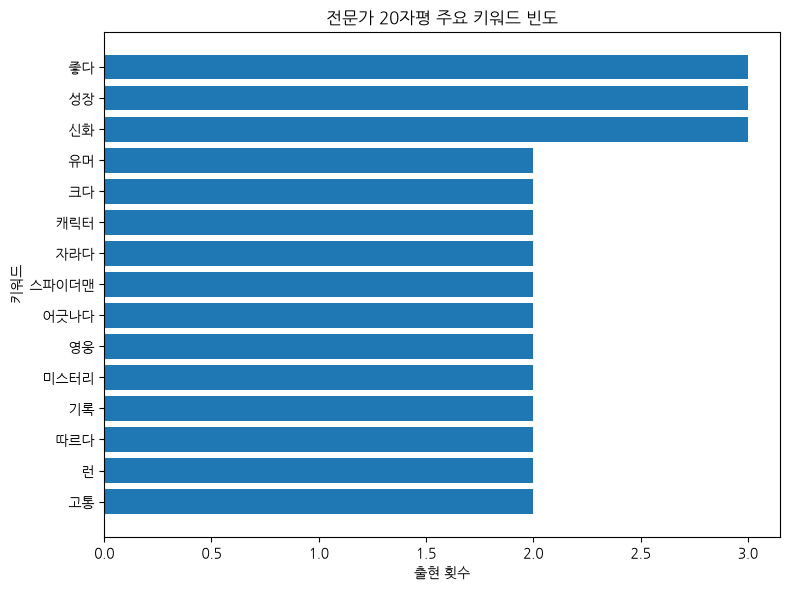

In [85]:
top_words = clean_word_freq.head(15).sort_values(
    "count",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_words["word"],
    top_words["count"]
)

plt.title("전문가 20자평 주요 키워드 빈도")
plt.xlabel("출현 횟수")
plt.ylabel("키워드")

plt.tight_layout()
plt.show()

#### 키워드 빈도 분석 결과

불용어 제거 후 전문가 20자평에서 반복적으로 등장한 단어를 확인한 결과,
`성장`, `신화`, `좋다`가 각각 3회로 가장 많이 나타났다.

이외에도 `영웅`, `미스터리`, `캐릭터`, `히어로`, `유머` 등
작품의 서사 구조나 캐릭터를 설명하는 표현이 반복적으로 확인되었다.

다만 전체 전문가 리뷰가 42건으로 많지 않고 대부분의 단어가 1~3회 수준으로 등장하므로,
단순 빈도만으로 전체 평가 경향을 일반화하기보다 이후 TF-IDF 분석을 통해
영화별로 상대적으로 특징적인 표현을 추가로 확인한다.

#### 영화별 TF-IDF 분석

단순 빈도는 전체 리뷰에서 자주 등장한 단어를 보여주지만,
특정 영화에서 상대적으로 특징적으로 사용된 표현을 구분하기는 어렵다.

따라서 같은 영화에 작성된 전문가 20자평의 정제 토큰을 하나의 문서로 통합하고,
각 영화 문서를 대상으로 TF-IDF를 계산하여 영화별 특징적인 키워드를 확인한다.

In [86]:
movie_documents = (
    critic_reviews
    .groupby("title")
    .agg(
        review_count=("review", "count"),
        document_tokens=(
            "clean_tokens",
            lambda token_lists: [
                token
                for tokens in token_lists
                for token in tokens
            ]
        )
    )
    .reset_index()
)

movie_documents["document"] = (
    movie_documents["document_tokens"]
    .apply(lambda tokens: " ".join(tokens))
)

movie_documents[
    ["title", "review_count", "document"]
]

,title,review_count,document
0,다윗,1,검 대신 악기 성경 뮤지컬
1,명탐정 코난: 하이웨이의 타천사,3,추리 직진 원점 회귀 따르다 덜컹거리다 곡선 박진감 롤러코스터 타다 같다 소년 스피...
2,사랑의 하츄핑: 고래보석의 전설,1,시네마 키드 육성 보다 자라다 어린이
3,스파이더맨: 브랜드 뉴 데이,9,하이틴 겉옷 근본 돌아가다 성장 크다 힘 크다 책임 서로 따르다 때 히어로 도파민 ...
4,어떻게 해야 했을까?,4,찍다 시작 고통 끊다 확장 고뇌 해결 과제 되다 쓰라리다 쇠락 비극 미스터리 기록 ...
5,오디세이,11,그리스 신화 놀런 만나다 오랫동안 기다리다 방식 죽음 죄책감 영웅 서사 좋다 싫다 ...
6,오케이 마담2,5,즐거움 전진 찌르다 빌 런 최수영 발견 엄마 아내 자신 인정 성장 유람선 액션 나룻...
7,퍼피 구조대: 더 다이노 무비,2,강아지 공룡 증명 시리즈 필승 조합 모험 다양 서머 어트랙션
8,호프,6,후진 없다 희망 트럭 쾌감 짝 공허 납득 끌리다 즐기다 낚이다 순식간 펼쳐지다 아수...


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    movie_documents["document"]
)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("영화 수:", tfidf_matrix.shape[0])
print("전체 키워드 수:", tfidf_matrix.shape[1])

영화 수: 9
전체 키워드 수: 184


In [88]:
tfidf_results = []

for i, title in enumerate(movie_documents["title"]):
    scores = tfidf_matrix[i].toarray().flatten()

    top_indices = scores.argsort()[::-1][:5]

    for rank, idx in enumerate(top_indices, start=1):
        tfidf_results.append({
            "title": title,
            "rank": rank,
            "keyword": feature_names[idx],
            "tfidf": scores[idx]
        })

tfidf_top5 = pd.DataFrame(tfidf_results)

tfidf_top5

,title,rank,keyword,tfidf
0,다윗,1,뮤지컬,0.447214
1,다윗,2,대신,0.447214
2,다윗,3,성경,0.447214
3,다윗,4,검,0.447214
4,다윗,5,악기,0.447214
5,명탐정 코난: 하이웨이의 타천사,1,회귀,0.265934
6,명탐정 코난: 하이웨이의 타천사,2,추리,0.265934
7,명탐정 코난: 하이웨이의 타천사,3,직진,0.265934
8,명탐정 코난: 하이웨이의 타천사,4,깔리다,0.265934
9,명탐정 코난: 하이웨이의 타천사,5,곡선,0.265934


In [89]:
tfidf_summary = (
    tfidf_top5
    .sort_values(["title", "rank"])
    .groupby("title")
    .agg(
        top_keywords=(
            "keyword",
            lambda x: " / ".join(x)
        )
    )
    .reset_index()
    .merge(
        movie_documents[
            ["title", "review_count"]
        ],
        on="title",
        how="left"
    )
)

tfidf_summary = tfidf_summary[
    ["title", "review_count", "top_keywords"]
]

tfidf_summary

,title,review_count,top_keywords
0,다윗,1,뮤지컬 / 대신 / 성경 / 검 / 악기
1,명탐정 코난: 하이웨이의 타천사,3,회귀 / 추리 / 직진 / 깔리다 / 곡선
2,사랑의 하츄핑: 고래보석의 전설,1,키드 / 보다 / 어린이 / 육성 / 시네마
3,스파이더맨: 브랜드 뉴 데이,9,히어로 / 크다 / 캐릭터 / 스파이더맨 / 성장
4,어떻게 해야 했을까?,4,기록 / 확장 / 일 / 해결 / 쓰라리다
5,오디세이,11,신화 / 어긋나다 / 놀런 / 좋다 / 함선
6,오케이 마담2,5,유머 / 후속 / 전개 / 인정 / 찌르다
7,퍼피 구조대: 더 다이노 무비,2,필승 / 조합 / 증명 / 공룡 / 모험
8,호프,6,후진 / 희망 / 페이소스 / 하루 / 트럭


#### TF-IDF 분석 결과

영화별 전문가 20자평을 하나의 문서로 통합하여 TF-IDF를 적용한 결과,
전체 빈도 분석에서는 드러나지 않았던 영화별 특징적인 표현을 확인할 수 있었다.

`오디세이`에서는 **신화, 놀란, 함선** 등 작품의 신화적 배경과 연출자를 직접적으로 나타내는 단어가,
`스파이더맨: 브랜드 뉴 데이`에서는 **히어로, 캐릭터, 성장** 등 히어로 서사와 인물의 성장에 관련된 표현이 특징적으로 나타났다.

`퍼피 구조대: 더 다이노 무비`에서는 **공룡, 모험, 조합**,
`오케이 마담2`에서는 **유머, 전개** 등의 표현이 상대적으로 높은 TF-IDF 값을 보여
각 영화의 장르와 서사적 특징이 전문가 20자평에도 반영되고 있음을 확인할 수 있었다.

다만 영화별 전문가 리뷰 수가 1건에서 11건까지 차이가 크며,
특히 리뷰가 1건뿐인 영화의 TF-IDF 결과는 해당 한 문장의 표현에 크게 의존한다.
따라서 TF-IDF 값의 절대적인 크기보다 영화별로 어떤 표현이 상대적으로 특징적으로 나타났는지를 중심으로 해석하였다.

#### 전문가 평점에 따른 표현 차이

영화별 특징적인 키워드에 이어,
전문가가 높은 점수를 준 리뷰와 낮은 점수를 준 리뷰에서
사용되는 표현에 차이가 있는지 추가로 확인한다.

단, 평점 구간을 임의로 먼저 설정하지 않고
전체 전문가 별점의 분포를 확인한 뒤 비교 기준을 결정한다.

In [90]:
score_distribution = (
    critic_reviews["critic_score"]
    .value_counts()
    .sort_index()
)

score_distribution

critic_score
4.0     1
5.0     6
6.0     7
7.0    19
8.0     6
9.0     3
Name: count, dtype: int64

In [91]:
print("평균:", critic_reviews["critic_score"].mean())
print("중앙값:", critic_reviews["critic_score"].median())
print("최솟값:", critic_reviews["critic_score"].min())
print("최댓값:", critic_reviews["critic_score"].max())

평균: 6.761904761904762
중앙값: 7.0
최솟값: 4.0
최댓값: 9.0


In [92]:
def classify_score(score):
    if score <= 6:
        return "저평점"
    elif score >= 8:
        return "고평점"
    else:
        return "중간"

critic_reviews["score_group"] = (
    critic_reviews["critic_score"]
    .apply(classify_score)
)

critic_reviews["score_group"].value_counts()

score_group
중간     19
저평점    14
고평점     9
Name: count, dtype: int64

In [93]:
critic_reviews[
    [
        "title",
        "critic_score",
        "score_group",
        "review"
    ]
].sort_values(
    "critic_score",
    ascending=False
)

,title,critic_score,score_group,review
6,오디세이,9.0,고평점,거대한 함선을 타고 신화와 영화 사이를 전속으로 항해하다
7,오디세이,9.0,고평점,"놀런, 인간의 탈을 쓴 영화의 신"
16,스파이더맨: 브랜드 뉴 데이,9.0,고평점,역대 가장 성숙한 스파이더맨의 탄생
1,오디세이,8.0,고평점,늘 해오던 걸 가장 잘 할 수 있는 방식으로
8,오디세이,8.0,고평점,"어마어마한 게 꼭 좋은 건 아니지만 적어도, 어설프게 어마어마한 것들을 가려내는 역..."
0,오디세이,8.0,고평점,그리스신화는 놀런을 만나길 오랫동안 기다려왔구나
31,호프,8.0,고평점,후진 없는 희망의 트럭
36,호프,8.0,고평점,"공백을 만들고, 응시하고, 추격한다 계속!"
19,스파이더맨: 브랜드 뉴 데이,8.0,고평점,아마도 마블의 새로운 미래
2,오디세이,7.0,중간,죽음과 죄책감을 등에 업은 영웅의 서사


평점 분포를 확인한 결과 중앙값인 7점에 리뷰가 가장 많이 집중되어 있었다.

따라서 7점을 어느 한 방향의 평가로 임의 분류하지 않고,
**6점 이하를 저평점, 8점 이상을 고평점, 7점을 중간 평가**로 구분하였다.

이후 표현 차이 분석에서는 평가 방향이 비교적 명확한
저평점 리뷰와 고평점 리뷰를 중심으로 비교한다.

In [94]:
score_group_tokens = {}

for group in ["고평점", "저평점"]:
    tokens = [
        token
        for token_list in critic_reviews.loc[
            critic_reviews["score_group"] == group,
            "clean_tokens"
        ]
        for token in token_list
    ]

    score_group_tokens[group] = tokens

    print(
        f"{group}: "
        f"리뷰 {sum(critic_reviews['score_group'] == group)}건, "
        f"토큰 {len(tokens)}개"
    )

고평점: 리뷰 9건, 토큰 36개
저평점: 리뷰 14건, 토큰 64개


In [95]:
group_word_rows = []

for group in ["고평점", "저평점"]:
    tokens = score_group_tokens[group]
    counts = Counter(tokens)
    total_tokens = len(tokens)

    for word, count in counts.items():
        group_word_rows.append({
            "score_group": group,
            "word": word,
            "count": count,
            "rate_per_100": count / total_tokens * 100
        })

group_word_freq = pd.DataFrame(group_word_rows)

group_word_compare = (
    group_word_freq
    .pivot(
        index="word",
        columns="score_group",
        values="rate_per_100"
    )
    .fillna(0)
    .reset_index()
)

group_word_compare["difference"] = (
    group_word_compare["고평점"]
    - group_word_compare["저평점"]
)

group_word_compare.sort_values(
    "difference",
    ascending=False
).head(15)

score_group,word,고평점,저평점,difference
47,신화,5.555556,0.0,5.555556
5,거대,2.777778,0.0,2.777778
2,가려내다,2.777778,0.0,2.777778
10,그리스,2.777778,0.0,2.777778
11,기다리다,2.777778,0.0,2.777778
19,놀다,2.777778,0.0,2.777778
8,공백,2.777778,0.0,2.777778
26,만나다,2.777778,0.0,2.777778
25,마블,2.777778,0.0,2.777778
30,미래,2.777778,0.0,2.777778


In [96]:
high_counts = Counter(score_group_tokens["고평점"])
low_counts = Counter(score_group_tokens["저평점"])

group_word_compare["total_count"] = (
    group_word_compare["word"].map(high_counts).fillna(0)
    + group_word_compare["word"].map(low_counts).fillna(0)
)

reliable_words = group_word_compare[
    group_word_compare["total_count"] >= 2
].copy()

print("[고평점에서 상대적으로 많이 사용된 단어]")
display(
    reliable_words
    .sort_values("difference", ascending=False)
    .head(10)
)

print("\n[저평점에서 상대적으로 많이 사용된 단어]")
display(
    reliable_words
    .sort_values("difference", ascending=True)
    .head(10)
)

[고평점에서 상대적으로 많이 사용된 단어]


score_group,word,고평점,저평점,difference,total_count
47,신화,5.555556,0.000,5.555556,2
24,런,0.000000,3.125,-3.125000,2
31,미스터리,0.000000,3.125,-3.125000,2
52,어긋나다,0.000000,3.125,-3.125000,2
62,유머,0.000000,3.125,-3.125000,2



[저평점에서 상대적으로 많이 사용된 단어]


score_group,word,고평점,저평점,difference,total_count
24,런,0.000000,3.125,-3.125000,2
31,미스터리,0.000000,3.125,-3.125000,2
52,어긋나다,0.000000,3.125,-3.125000,2
62,유머,0.000000,3.125,-3.125000,2
47,신화,5.555556,0.000,5.555556,2


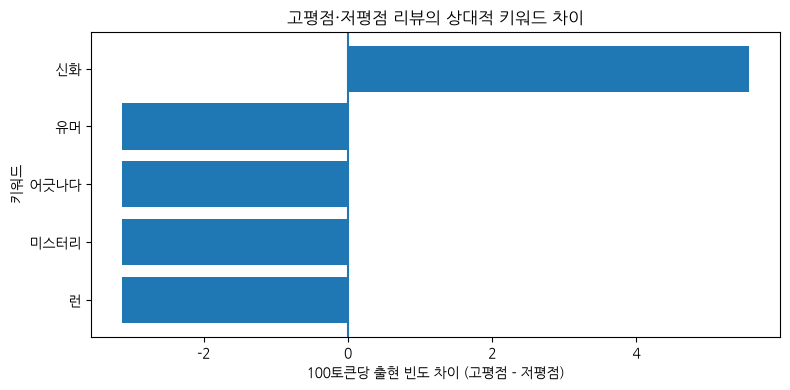

In [97]:
plot_words = (
    reliable_words
    .sort_values("difference")
)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_words["word"],
    plot_words["difference"]
)

plt.axvline(0)

plt.title("고평점·저평점 리뷰의 상대적 키워드 차이")
plt.xlabel("100토큰당 출현 빈도 차이 (고평점 - 저평점)")
plt.ylabel("키워드")

plt.tight_layout()
plt.show()

#### 평점별 표현 차이 분석 결과

고평점(8점 이상)과 저평점(6점 이하) 리뷰의 토큰 수가 서로 달라,
단순 출현 횟수 대신 100토큰당 출현 빈도를 기준으로 표현 차이를 비교하였다.

또한 한 번만 등장한 단어가 결과를 크게 좌우하는 것을 줄이기 위해
두 그룹을 합쳐 최소 2회 이상 등장한 단어만 비교하였다.

그 결과 고평점 리뷰에서는 `신화`가 상대적으로 더 많이 나타났으며,
저평점 리뷰에서는 `미스터리`, `유머`, `어긋나다` 등의 표현이 상대적으로 더 많이 확인되었다.

다만 조건을 충족한 단어가 5개에 불과하고 각 단어의 전체 출현 횟수도 2회 수준이어서,
평점에 따라 사용 언어가 뚜렷하게 구분된다고 일반화하기는 어렵다.

따라서 본 결과는 평점별 표현 차이에 대한 탐색적 분석으로 해석하며,
현재 데이터에서는 영화별 TF-IDF 분석이 평점 그룹별 키워드 비교보다
작품별 평가 특성을 설명하는 데 더 유용한 것으로 판단하였다.

### 5.2 장기 박스오피스 데이터를 활용한 요일 패턴 재검증

최근 14일 분석에서는 주말의 Top10 평균 관객수가 평일보다 약 2.10배 높게 나타났으며,
상영횟수 증가보다 상영 1회당 관객수 증가가 더 두드러졌다.

그러나 2주간의 데이터만으로 해당 패턴을 일반적인 요일 효과로 해석하기에는 관측기간이 짧다는 한계가 있다.

이에 KOBIS 일별 박스오피스 데이터를 추가로 수집하여
**2025-08-15부터 2026-08-14까지 최근 1년의 요일별 관객 패턴을 재검증**한다.

In [98]:
long_start_date = datetime(2025, 8, 15)
long_end_date = datetime(2026, 8, 14)

long_dates = pd.date_range(
    start=long_start_date,
    end=long_end_date,
    freq="D"
)

print("시작일:", long_dates.min().strftime("%Y-%m-%d"))
print("종료일:", long_dates.max().strftime("%Y-%m-%d"))
print("수집 일수:", len(long_dates))

시작일: 2025-08-15
종료일: 2026-08-14
수집 일수: 365


In [99]:
long_kobis_list = []
failed_dates = []

for i, date in enumerate(long_dates, start=1):
    target_date = date.strftime("%Y%m%d")

    params = {
        "key": KOBIS_API_KEY,
        "targetDt": target_date
    }

    try:
        response = requests.get(
            KOBIS_URL,
            params=params,
            timeout=10
        )

        response.raise_for_status()

        data = response.json()

        daily_list = data[
            "boxOfficeResult"
        ]["dailyBoxOfficeList"]

        for movie in daily_list:
            long_kobis_list.append({
                "date": target_date,
                "rank": movie["rank"],
                "movieCd": movie["movieCd"],
                "movieNm": movie["movieNm"],
                "openDt": movie["openDt"],
                "audiCnt": movie["audiCnt"],
                "audiAcc": movie["audiAcc"],
                "salesAmt": movie["salesAmt"],
                "salesAcc": movie["salesAcc"],
                "scrnCnt": movie["scrnCnt"],
                "showCnt": movie["showCnt"]
            })

    except Exception as e:
        failed_dates.append(target_date)
        print(f"수집 실패: {target_date} / {e}")

    # 진행상황은 50일마다 출력
    if i % 50 == 0 or i == len(long_dates):
        print(
            f"{i}/{len(long_dates)}일 처리 완료 "
            f"- 현재 {len(long_kobis_list):,}행"
        )

    time.sleep(0.2)

50/365일 처리 완료 - 현재 500행
100/365일 처리 완료 - 현재 1,000행
150/365일 처리 완료 - 현재 1,500행
200/365일 처리 완료 - 현재 2,000행
250/365일 처리 완료 - 현재 2,500행
300/365일 처리 완료 - 현재 3,000행
350/365일 처리 완료 - 현재 3,500행
365/365일 처리 완료 - 현재 3,650행


In [100]:
kobis_1y = pd.DataFrame(long_kobis_list)

print("전체 행 수:", len(kobis_1y))
print("수집 날짜 수:", kobis_1y["date"].nunique())
print("실패 날짜 수:", len(failed_dates))

print("\n날짜별 영화 수")
print(kobis_1y.groupby("date").size().value_counts())

전체 행 수: 3650
수집 날짜 수: 365
실패 날짜 수: 0

날짜별 영화 수
10    365
Name: count, dtype: int64


In [101]:
numeric_cols_1y = [
    "rank",
    "audiCnt",
    "audiAcc",
    "salesAmt",
    "salesAcc",
    "scrnCnt",
    "showCnt"
]

kobis_1y[numeric_cols_1y] = (
    kobis_1y[numeric_cols_1y]
    .apply(pd.to_numeric)
)

kobis_1y["date"] = pd.to_datetime(
    kobis_1y["date"],
    format="%Y%m%d"
)

kobis_1y["openDt"] = pd.to_datetime(
    kobis_1y["openDt"],
    errors="coerce"
)

print(kobis_1y.dtypes)

date        datetime64[us]
rank                 int64
movieCd                str
movieNm                str
openDt      datetime64[us]
audiCnt              int64
audiAcc              int64
salesAmt             int64
salesAcc             int64
scrnCnt              int64
showCnt              int64
dtype: object


In [102]:
print("KOBIS 1년 데이터 결측치")
print(kobis_1y.isnull().sum())

kobis_1y.to_csv(
    data_dir / "kobis_daily_boxoffice_1y.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nKOBIS 1년 CSV 저장 완료")

KOBIS 1년 데이터 결측치
date        0
rank        0
movieCd     0
movieNm     0
openDt      8
audiCnt     0
audiAcc     0
salesAmt    0
salesAcc    0
scrnCnt     0
showCnt     0
dtype: int64

KOBIS 1년 CSV 저장 완료


In [103]:
daily_1y = (
    kobis_1y
    .groupby("date")
    .agg(
        total_audience=("audiCnt", "sum"),
        total_sales=("salesAmt", "sum"),
        total_show_count=("showCnt", "sum")
    )
    .reset_index()
)

daily_1y["weekday"] = (
    daily_1y["date"]
    .dt.dayofweek
    .map(weekday_map)
)

daily_1y["is_weekend"] = (
    daily_1y["date"]
    .dt.dayofweek
    .isin([5, 6])
)

daily_1y["audience_per_show"] = (
    daily_1y["total_audience"]
    / daily_1y["total_show_count"]
)

print("날짜 수:", len(daily_1y))

daily_1y.head()

날짜 수: 365


,date,total_audience,total_sales,total_show_count,weekday,is_weekend,audience_per_show
0,2025-08-15,618277,6323513030,16280,금,False,37.977703
1,2025-08-16,553060,5763850790,16013,토,True,34.538188
2,2025-08-17,455365,4676093740,14960,일,True,30.438837
3,2025-08-18,142234,1400825000,12793,월,False,11.118111
4,2025-08-19,132869,1298717150,12566,화,False,10.573691


In [104]:
weekend_1y = (
    daily_1y
    .groupby("is_weekend")
    .agg(
        avg_audience=("total_audience", "mean"),
        avg_show_count=("total_show_count", "mean"),
        avg_audience_per_show=("audience_per_show", "mean")
    )
)

weekend_1y.index = [
    "평일" if not x else "주말"
    for x in weekend_1y.index
]

# 1년 데이터 배율 계산
audience_ratio_1y = (
    weekend_1y.loc["주말", "avg_audience"]
    / weekend_1y.loc["평일", "avg_audience"]
)

show_ratio_1y = (
    weekend_1y.loc["주말", "avg_show_count"]
    / weekend_1y.loc["평일", "avg_show_count"]
)

efficiency_ratio_1y = (
    weekend_1y.loc["주말", "avg_audience_per_show"]
    / weekend_1y.loc["평일", "avg_audience_per_show"]
)

display(weekend_1y)

print(f"주말 / 평일 관객수: {audience_ratio_1y:.2f}배")
print(f"주말 / 평일 상영횟수: {show_ratio_1y:.2f}배")
print(f"주말 / 평일 상영 1회당 관객수: {efficiency_ratio_1y:.2f}배")

,avg_audience,avg_show_count,avg_audience_per_show
평일,241037.356322,13000.727969,17.485456
주말,515445.375000,15083.384615,33.805080


주말 / 평일 관객수: 2.14배
주말 / 평일 상영횟수: 1.16배
주말 / 평일 상영 1회당 관객수: 1.93배


In [105]:
period_compare = pd.DataFrame({
    "지표": [
        "주말 / 평일 관객수",
        "주말 / 평일 상영횟수",
        "주말 / 평일 상영 1회당 관객수"
    ],
    "최근 14일": [
        audience_ratio,
        show_ratio,
        efficiency_ratio
    ],
    "최근 1년": [
        audience_ratio_1y,
        show_ratio_1y,
        efficiency_ratio_1y
    ]
})

period_compare

,지표,최근 14일,최근 1년
0,주말 / 평일 관객수,2.102453,2.138446
1,주말 / 평일 상영횟수,1.068749,1.160195
2,주말 / 평일 상영 1회당 관객수,1.972385,1.933326


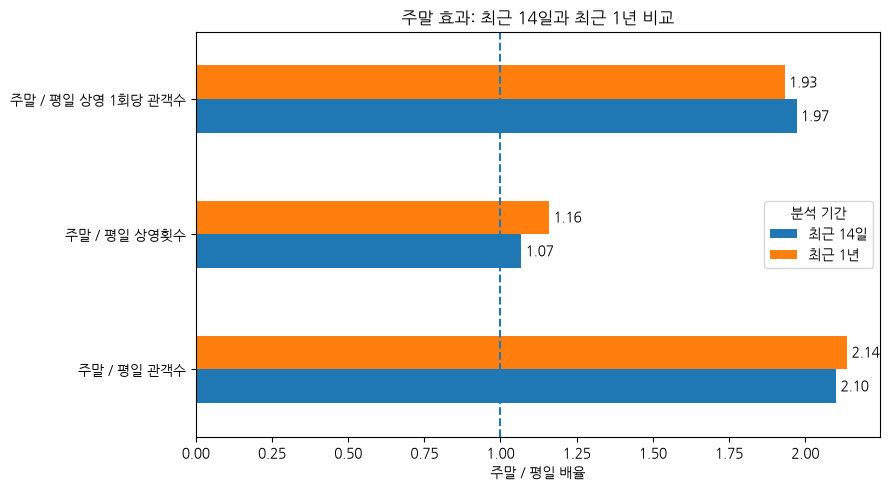

In [106]:
compare_plot = (
    period_compare
    .set_index("지표")[
        ["최근 14일", "최근 1년"]
    ]
)

ax = compare_plot.plot(
    kind="barh",
    figsize=(9, 5)
)

ax.axvline(
    1,
    linestyle="--"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("주말 효과: 최근 14일과 최근 1년 비교")
plt.xlabel("주말 / 평일 배율")
plt.ylabel("")
plt.legend(title="분석 기간")
plt.tight_layout()
plt.show()

#### 장기 데이터 재검증 결과

최근 14일 분석에서 확인한 주말 효과가 단기적인 현상인지 확인하기 위해
동일한 지표를 최근 1년의 KOBIS 일별 Top10 데이터로 확장하여 재검증하였다.

비교 결과, 주말 평균 관객수는 평일 대비
최근 14일에서 **2.10배**, 최근 1년에서 **2.14배**로 나타나 거의 동일한 수준을 유지하였다.

상영횟수는 최근 14일 **1.07배**, 최근 1년 **1.16배**로 증가 폭이 상대적으로 작았으며,
상영 1회당 관객수는 각각 **1.97배**, **1.93배**로 두 기간 모두 평일의 약 2배 수준이었다.

따라서 최근 14일에서 관찰된 **주말 관객 증가 패턴은 1년 데이터에서도 일관되게 확인되었다.**
특히 주말의 관객수 증가 폭에 비해 상영횟수 증가 폭은 제한적이었고,
상영 1회당 관객수가 크게 증가하는 구조 역시 장기 데이터에서 유지되었다.

이는 주말 흥행 규모 확대가 단순한 상영 공급 증가만으로 설명되기보다
**각 상영 회차에 집중되는 관객 수요 증가와 함께 나타나는 패턴**임을 보여준다.

다만 해당 분석은 관찰 데이터에 기반하므로,
주말이라는 요인이 관객수를 직접 증가시킨다고 인과적으로 해석할 수는 없다.
공휴일, 방학·휴가철, 신작 개봉 일정, 대형 흥행작 등 시간에 따라 달라지는 요인도 함께 영향을 미칠 수 있다.

#### 평일·주말 관객수 차이 검정

1년 데이터에서 확인된 평일과 주말의 관객수 차이가 일부 날짜의 극단적인 값에 의한 것인지 추가로 확인한다.

일별 관객수는 대형 흥행작, 공휴일 등의 영향으로 분포가 치우칠 수 있으므로
정규분포를 가정하지 않는 Mann–Whitney U 검정을 사용한다.

또한 p-value뿐 아니라 두 집단 차이의 크기를 확인하기 위해
rank-biserial correlation을 함께 계산한다.

In [107]:
from scipy.stats import mannwhitneyu

weekday_audience = daily_1y.loc[
    ~daily_1y["is_weekend"],
    "total_audience"
]

weekend_audience = daily_1y.loc[
    daily_1y["is_weekend"],
    "total_audience"
]

u_stat, p_value = mannwhitneyu(
    weekend_audience,
    weekday_audience,
    alternative="two-sided"
)

n_weekend = len(weekend_audience)
n_weekday = len(weekday_audience)

rank_biserial = (
    2 * u_stat / (n_weekend * n_weekday)
    - 1
)

print("평일 일수:", n_weekday)
print("주말 일수:", n_weekend)
print(f"Mann-Whitney U: {u_stat:.0f}")
print(f"p-value: {p_value:.6f}")
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

평일 일수: 261
주말 일수: 104
Mann-Whitney U: 23684
p-value: 0.000000
Rank-biserial correlation: 0.745


#### 평일·주말 관객수 차이 검정 결과

최근 1년의 일별 Top10 관객수를 대상으로 평일 261일과 주말 104일의 분포를 비교한 결과,
Mann–Whitney U 검정에서 **통계적으로 유의한 차이(p < 0.001)**가 확인되었다.

또한 rank-biserial correlation은 **0.745**로 나타나,
평일과 주말 관객수의 차이가 단순히 표본 수가 많아 통계적으로 유의해진 수준을 넘어
실질적으로도 큰 차이를 보이는 것으로 확인되었다.

따라서 최근 14일 분석에서 관찰된 주말 관객 증가 패턴은
1년 데이터에서도 평균값뿐 아니라 전체 관객수 분포 차이에서도 일관되게 확인되었다.

다만 이는 관찰 데이터에 기반한 집단 간 차이이므로
주말이라는 요인이 관객수를 직접 증가시키는 인과관계로 해석할 수는 없다.
공휴일, 방학·휴가철, 신작 개봉 일정 및 대형 흥행작 등 다른 시간적 요인의 영향도 함께 고려할 필요가 있다.

## 6. 종합 결론 및 한계점

### 6.1 종합 결론

본 프로젝트에서는 씨네21 웹 스크래핑과 KOBIS Open API를 활용하여 영화 데이터를 직접 수집하고,
현재 박스오피스 상위 영화의 작품 특성, 전문가 평가, 실제 흥행 성과 및 시간에 따른 관객 패턴을 분석하였다.

첫째, 현재 씨네21 박스오피스 상위권의 작품 특성을 살펴본 결과
상세정보가 확인된 9편 중 **액션과 애니메이션 장르가 각각 4편으로 가장 많이 나타났으며**,
관람등급은 전체 관람가·12세이상관람가·15세이상관람가가 각각 3편씩 분포하였다.
제작 국가는 미국 4편, 한국 3편, 일본 2편으로 국내외 작품이 함께 상위권을 구성하고 있었다.

둘째, 씨네21 전문가 평가와 KOBIS 흥행 성과를 연결한 결과
공통으로 확인된 9편에서는 **전문가 평균 평점이 높은 영화일수록 흥행 성과도 높은 경향**이 나타났다.
전문가 평점과 관측기간 관객수의 Spearman 상관계수는 0.912였으며,
Top10 등장일 기준 일평균 관객수와 비교한 경우에도 0.854로 높은 양의 관계가 유지되었다.
다만 표본이 9편으로 작고 이미 박스오피스 상위권에 진입한 영화를 대상으로 한 결과이므로,
전문가 평가가 흥행을 직접적으로 높인다고 해석하지 않았다.

셋째, 최근 14일 KOBIS 데이터에서는 **상영 기회와 흥행 규모가 매우 강하게 함께 움직이는 패턴**이 확인되었다.
하루 평균 관객수는 평균 상영횟수와 Pearson 0.986,
평균 스크린 수와 Pearson 0.955의 높은 양의 관계를 보였다.
그러나 상영 1회당 관객수와 스크린 운영 밀도를 함께 비교한 결과,
같은 흥행 상위권에서도 상영 기회를 실제 관객으로 전환하는 효율과 운영 방식에는 영화별 차이가 존재하였다.

넷째, 최근 14일의 일별 관객수에서는 **토·일요일에 관객이 크게 증가하는 반복적인 패턴**이 확인되었다.
주말 평균 관객수는 평일의 2.10배였지만 평균 상영횟수는 1.07배에 그쳤고,
상영 1회당 관객수는 1.97배로 증가하였다.
따라서 해당 기간의 주말 흥행 확대는 단순한 상영 공급 증가보다
각 상영 회차에 집중되는 관객 수요 증가가 더 두드러지는 형태로 나타났다.

추가로 2주라는 짧은 관측기간의 한계를 보완하기 위해
KOBIS 데이터를 최근 1년, 총 3,650건으로 확장하여 동일한 패턴을 재검증하였다.
그 결과 주말/평일 관객수 배율은 **2.14배**, 상영 1회당 관객수는 **1.93배**로 나타나
14일 분석과 유사한 패턴이 장기 데이터에서도 유지되었다.
Mann–Whitney U 검정에서도 평일과 주말 관객수 분포의 차이가 통계적으로 유의했으며(p < 0.001),
rank-biserial correlation은 0.745로 나타났다.

마지막으로 42건의 전문가 20자평을 형태소 분석하고 TF-IDF를 적용한 결과,
단순 빈도에서는 `성장`, `신화`, `좋다` 등의 표현이 반복적으로 나타났으며,
영화별 TF-IDF에서는 작품의 장르·서사·캐릭터와 관련된 서로 다른 특징적 표현을 확인할 수 있었다.
반면 고평점과 저평점 리뷰의 표현 차이는 표본과 반복 단어가 부족하여 뚜렷하게 일반화하기 어려웠으며,
현재 데이터에서는 **평점 그룹 비교보다 영화별 TF-IDF가 작품별 평가 특성을 설명하는 데 더 적합한 분석**으로 판단하였다.

### 6.2 한계점 및 향후 개선 방향

#### 1) 씨네21 분석 대상의 표본 크기

씨네21 메인 페이지에서 수집한 박스오피스 데이터는 Top10으로 제한되어 있으며,
이 중 1편은 상세페이지가 제공되지 않아 작품 특성 및 전문가 평가 분석에는 9편만 활용하였다.

특히 전문가 평점과 흥행 성과의 관계 분석 역시 공통으로 확인된 9편을 대상으로 하였기 때문에,
현재 상위권 영화에서 관찰된 관계를 전체 영화에 일반화하기에는 표본이 작다.

향후에는 씨네21의 영화 데이터를 더 넓은 범위로 수집하거나
과거 박스오피스 영화까지 포함하여 표본을 확대한다면
전문가 평가와 흥행 성과의 관계를 보다 안정적으로 검증할 수 있다.


#### 2) 전문가 리뷰 수의 불균형

영화별 전문가 리뷰 수가 1건에서 11건까지 차이가 있어
동일한 평균 평점이라도 평가에 참여한 전문가 수에 따라 안정성이 다를 수 있다.

또한 42건의 20자평만으로 고평점과 저평점의 언어 사용 차이를 비교한 결과,
반복적으로 등장하는 단어가 많지 않아 뚜렷한 평가 언어 차이를 일반화하기 어려웠다.

향후 더 많은 영화와 전문가 리뷰를 확보한다면
리뷰 수에 따른 불확실성을 함께 고려하거나,
평점 구간별 텍스트 특징을 보다 안정적으로 비교할 수 있다.


#### 3) 관찰 데이터 기반 분석의 인과관계 한계

상영횟수·스크린 수와 관객수 사이에 매우 높은 상관관계가 확인되었지만,
이를 상영 기회가 관객수를 증가시킨 직접적인 원인으로 해석할 수는 없다.

흥행 수요가 높은 영화에 극장이 더 많은 스크린과 상영횟수를 배정했을 가능성도 있어
상영 기회와 관객수 사이에는 양방향 관계가 존재할 수 있다.

향후 개봉 전 예매량, 마케팅 규모, 배급사, 경쟁작 수, 좌석 수 및 상영 시간대 등의 변수를 추가한다면
흥행 성과에 영향을 미치는 요인을 보다 세분화하여 분석할 수 있다.


#### 4) 시간적 요인의 통제 부족

최근 1년 데이터에서도 주말 관객 증가 패턴이 일관되게 확인되었지만,
주말 여부 외에도 공휴일, 방학·휴가철, 명절, 신작 개봉일, 대형 흥행작 등의 요인이
일별 관객수에 함께 영향을 미칠 수 있다.

따라서 현재 분석은 주말과 관객수 사이의 반복적인 패턴을 확인한 것으로 해석하며,
주말 자체의 독립적인 효과를 추정한 결과는 아니다.

향후 공휴일 여부, 월·계절, 개봉 요일, 개봉 후 경과일 등의 변수를 추가하여
요일 효과와 다른 시간적 요인을 분리해 분석할 수 있다.


#### 5) 데이터 출처 간 기준 차이

씨네21과 KOBIS는 서로 다른 시점과 기준으로 제공되는 데이터이며,
두 출처에서 사용하는 영화 식별자도 서로 다르다.

본 분석에서는 공통 영화 제목을 기준으로 데이터를 연결했으나,
동일 제목의 다른 영화나 제목 표기 차이가 존재하는 경우 잘못 연결될 가능성이 있다.

향후 영화명뿐 아니라 개봉일, 감독, 제작 국가 등의 정보를 함께 활용한 매칭 기준을 적용하면
출처 간 데이터 연결의 정확도를 높일 수 있다.

## 7. 프로젝트 마무리

본 프로젝트에서는 웹 스크래핑과 Open API를 이용해 영화 데이터를 직접 수집하고,
서로 다른 출처의 데이터를 연결하여 현재 박스오피스의 작품 특성과 흥행 패턴을 분석하였다.

씨네21에서는 박스오피스 Top10의 기본·상세 정보와 전문가 평가 및 20자평을 수집하였고,
KOBIS에서는 최근 14일의 일별 박스오피스 데이터를 수집하여 관객수·매출액·스크린 수·상영횟수 등의 흥행 지표를 분석하였다.

분석 과정에서는 단순한 수치 비교에 그치지 않고,
전문가 평가와 흥행 성과의 관계, 상영 기회와 관객 동원 효율,
요일에 따른 관객 패턴을 살펴보았다.

또한 최근 14일 분석에서 발견한 주말 관객 증가 패턴의 짧은 관측기간이라는 한계를 보완하기 위해
최근 1년의 KOBIS 데이터 3,650건을 추가 수집하여 동일한 지표를 재검증하였다.

텍스트 분석에서는 전문가 20자평에 형태소 분석과 TF-IDF를 적용하여
전체 리뷰에서 반복되는 표현과 영화별 특징적인 평가 키워드를 탐색하였다.

이를 통해 데이터 수집부터 전처리, 탐색적 데이터 분석, 통계적 검증, 텍스트 분석까지
하나의 분석 흐름으로 구성하였다.